<a href="https://colab.research.google.com/github/sukritmodak/explainable_ai_diabetic_retinopathy/blob/main/Explainable_AI_Diabetic_Retinopathy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os

print(os.listdir('/content/drive/MyDrive/DR_Project'))

['B. Disease Grading']


In [11]:
import os

path = '/content/drive/MyDrive/DR_Project/B. Disease Grading'

print(os.listdir(path))

['B. Disease Grading']


In [12]:
import os

path = '/content/drive/MyDrive/DR_Project/B. Disease Grading'

print(os.listdir(path))

['B. Disease Grading']


In [13]:
import os

path = "/content/drive/MyDrive/DR_Project/B. Disease Grading"

print("Inside B. Disease Grading:")
print(os.listdir(path))

Inside B. Disease Grading:
['B. Disease Grading']


In [14]:
import os

path = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading"

print(os.listdir(path))

['LICENSE.txt', 'CC-BY-4.0.txt', '1. Original Images', '2. Groundtruths']


In [15]:
import os

image_path = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/1. Original Images"

print(os.listdir(image_path)[:10])

['a. Training Set', 'b. Testing Set']


In [16]:
import os

train_path = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set"

files = os.listdir(train_path)

print("Number of files:", len(files))
print("First 10 files:", files[:10])

Number of files: 413
First 10 files: ['IDRiD_226.jpg', 'IDRiD_041.jpg', 'IDRiD_083.jpg', 'IDRiD_099.jpg', 'IDRiD_296.jpg', 'IDRiD_026.jpg', 'IDRiD_019.jpg', 'IDRiD_002.jpg', 'IDRiD_001.jpg', 'IDRiD_031.jpg']


In [17]:
import os

test_path = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/1. Original Images/b. Testing Set"

files = os.listdir(test_path)

print("Number of testing images:", len(files))
print("First 10 files:", files[:10])

Number of testing images: 103
First 10 files: ['IDRiD_035.jpg', 'IDRiD_006.jpg', 'IDRiD_014.jpg', 'IDRiD_038.jpg', 'IDRiD_016.jpg', 'IDRiD_052.jpg', 'IDRiD_004.jpg', 'IDRiD_009.jpg', 'IDRiD_012.jpg', 'IDRiD_053.jpg']


In [18]:
import os

groundtruth_path = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/2. Groundtruths"

print(os.listdir(groundtruth_path))

['a. IDRiD_Disease Grading_Training Labels.csv', 'b. IDRiD_Disease Grading_Testing Labels.csv']


In [19]:
import pandas as pd

label_path = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv"

labels = pd.read_csv(label_path)

print(labels.head())
print("\nColumn names:")
print(labels.columns.tolist())

  Image name  Retinopathy grade  Risk of macular edema   Unnamed: 3  \
0  IDRiD_001                  3                       2         NaN   
1  IDRiD_002                  3                       2         NaN   
2  IDRiD_003                  2                       2         NaN   
3  IDRiD_004                  3                       2         NaN   
4  IDRiD_005                  4                       0         NaN   

   Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  \
0         NaN         NaN         NaN         NaN         NaN         NaN   
1         NaN         NaN         NaN         NaN         NaN         NaN   
2         NaN         NaN         NaN         NaN         NaN         NaN   
3         NaN         NaN         NaN         NaN         NaN         NaN   
4         NaN         NaN         NaN         NaN         NaN         NaN   

   Unnamed: 10 Unnamed: 11  
0          NaN         NaN  
1          NaN         NaN  
2          NaN         

In [20]:
print(labels['Retinopathy grade'].value_counts().sort_index())

Retinopathy grade
0    134
1     20
2    136
3     74
4     49
Name: count, dtype: int64


Image size: (4288, 2848)
Image mode: RGB


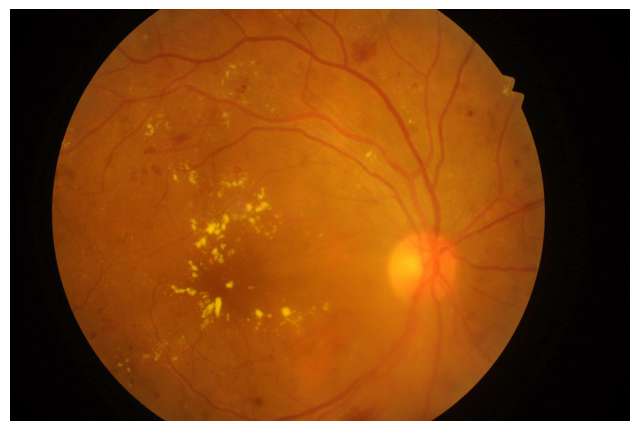

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set/IDRiD_001.jpg"

img = Image.open(image_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [22]:
import pandas as pd

test_label_path = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/2. Groundtruths/b. IDRiD_Disease Grading_Testing Labels.csv"

test_labels = pd.read_csv(test_label_path)

print(test_labels.head())
print("\nColumn names:")
print(test_labels.columns.tolist())

  Image name  Retinopathy grade  Risk of macular edema 
0  IDRiD_001                  4                       0
1  IDRiD_002                  4                       1
2  IDRiD_003                  4                       0
3  IDRiD_004                  4                       0
4  IDRiD_005                  4                       1

Column names:
['Image name', 'Retinopathy grade', 'Risk of macular edema ']


In [23]:
import os

test_image_folder = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/1. Original Images/b. Testing Set"

test_images = [
    f for f in os.listdir(test_image_folder)
    if f.lower().endswith(".jpg")
]

print("Number of testing images:", len(test_images))
print("First 10 images:")
print(test_images[:10])

Number of testing images: 103
First 10 images:
['IDRiD_035.jpg', 'IDRiD_006.jpg', 'IDRiD_014.jpg', 'IDRiD_038.jpg', 'IDRiD_016.jpg', 'IDRiD_052.jpg', 'IDRiD_004.jpg', 'IDRiD_009.jpg', 'IDRiD_012.jpg', 'IDRiD_053.jpg']


In [24]:
train_image_folder = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set"

train_data = labels[["Image name", "Retinopathy grade"]].copy()

train_data["Image path"] = train_data["Image name"].apply(
    lambda x: os.path.join(train_image_folder, x + ".jpg")
)

print(train_data.head())
print("\nTotal training records:", len(train_data))

  Image name  Retinopathy grade  \
0  IDRiD_001                  3   
1  IDRiD_002                  3   
2  IDRiD_003                  2   
3  IDRiD_004                  3   
4  IDRiD_005                  4   

                                          Image path  
0  /content/drive/MyDrive/DR_Project/B. Disease G...  
1  /content/drive/MyDrive/DR_Project/B. Disease G...  
2  /content/drive/MyDrive/DR_Project/B. Disease G...  
3  /content/drive/MyDrive/DR_Project/B. Disease G...  
4  /content/drive/MyDrive/DR_Project/B. Disease G...  

Total training records: 413


In [25]:
train_data["File exists"] = train_data["Image path"].apply(os.path.exists)

print("Files found:", train_data["File exists"].sum())
print("Files missing:", (~train_data["File exists"]).sum())

Files found: 413
Files missing: 0


In [26]:
print(train_data["Retinopathy grade"].value_counts().sort_index())

Retinopathy grade
0    134
1     20
2    136
3     74
4     49
Name: count, dtype: int64


In [27]:
print("Missing DR grades:", train_data["Retinopathy grade"].isna().sum())

Missing DR grades: 0


In [28]:
print("Unique DR grades:")
print(sorted(train_data["Retinopathy grade"].unique()))

Unique DR grades:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [29]:
print("Duplicate image names:", train_data["Image name"].duplicated().sum())

Duplicate image names: 0


In [30]:
from PIL import Image

for path in train_data["Image path"].head(5):
    img = Image.open(path)
    print(train_data.loc[train_data["Image path"] == path, "Image name"].iloc[0],
          "→", img.size)

IDRiD_001 → (4288, 2848)
IDRiD_002 → (4288, 2848)
IDRiD_003 → (4288, 2848)
IDRiD_004 → (4288, 2848)
IDRiD_005 → (4288, 2848)


In [31]:
for path in train_data["Image path"].head(5):
    img = Image.open(path)
    print(
        train_data.loc[train_data["Image path"] == path, "Image name"].iloc[0],
        "→", img.mode
    )

IDRiD_001 → RGB
IDRiD_002 → RGB
IDRiD_003 → RGB
IDRiD_004 → RGB
IDRiD_005 → RGB


In [32]:
print("Training images:", len(train_data))
print("Image format: RGB")
print("Image size: 4288 × 2848")
print("DR grades:", sorted(train_data["Retinopathy grade"].unique()))
print("Missing labels:", train_data["Retinopathy grade"].isna().sum())
print("Duplicate images:", train_data["Image name"].duplicated().sum())

Training images: 413
Image format: RGB
Image size: 4288 × 2848
DR grades: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Missing labels: 0
Duplicate images: 0


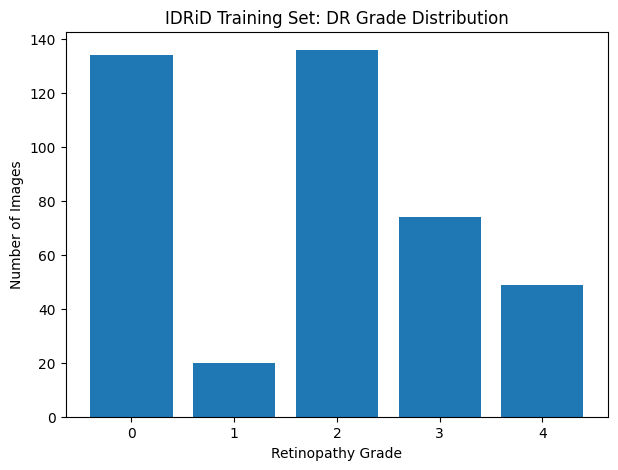

In [33]:
import matplotlib.pyplot as plt

grade_counts = train_data["Retinopathy grade"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(grade_counts.index.astype(str), grade_counts.values)

plt.xlabel("Retinopathy Grade")
plt.ylabel("Number of Images")
plt.title("IDRiD Training Set: DR Grade Distribution")

plt.show()

In [34]:
import tensorflow as tf
import numpy as np

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [35]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [36]:
IMG_SIZE = 224

print("Model image size:", IMG_SIZE, "×", IMG_SIZE)

Model image size: 224 × 224


In [37]:
from PIL import Image

test_img = Image.open(train_data["Image path"].iloc[0])

print("Original size:", test_img.size)

test_img_resized = test_img.resize((IMG_SIZE, IMG_SIZE))

print("Resized size:", test_img_resized.size)

Original size: (4288, 2848)
Resized size: (224, 224)


In [38]:
import numpy as np

img_array = np.array(test_img_resized)

print("Array shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

Array shape: (224, 224, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [39]:
img_normalized = img_array / 255.0

print("Minimum value:", img_normalized.min())
print("Maximum value:", img_normalized.max())
print("Data type:", img_normalized.dtype)

Minimum value: 0.0
Maximum value: 1.0
Data type: float64


In [40]:
img_normalized = img_normalized.astype(np.float32)

print("Data type:", img_normalized.dtype)
print("Shape:", img_normalized.shape)

Data type: float32
Shape: (224, 224, 3)


In [41]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(
    train_data["Retinopathy grade"],
    num_classes=5
)

print("Label shape:", y_train.shape)
print("First label:", y_train[0])

Label shape: (413, 5)
First label: [0. 0. 0. 1. 0.]


In [42]:
print("Total labels:", len(y_train))
print("Number of classes:", y_train.shape[1])
print("Each label has one class:", np.all(y_train.sum(axis=1) == 1))

Total labels: 413
Number of classes: 5
Each label has one class: True


In [44]:
from PIL import Image
import numpy as np

X_train = []

for path in train_data["Image path"]:
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img).astype(np.float32) / 255.0
    X_train.append(img)

X_train = np.array(X_train)

print("X_train shape:", X_train.shape)
print("X_train dtype:", X_train.dtype)

X_train shape: (413, 224, 224, 3)
X_train dtype: float32


In [45]:
print("X_train memory:", X_train.nbytes / (1024**2), "MB")


X_train memory: 237.15234375 MB


In [46]:
print("Images:", X_train.shape[0])
print("Labels:", y_train.shape[0])
print("Match:", X_train.shape[0] == y_train.shape[0])

Images: 413
Labels: 413
Match: True


In [47]:
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=np.argmax(y_train, axis=1)
)

print("Training images:", X_train_split.shape[0])
print("Validation images:", X_val.shape[0])
print("Training labels:", y_train_split.shape)
print("Validation labels:", y_val.shape)

Training images: 330
Validation images: 83
Training labels: (330, 5)
Validation labels: (83, 5)


In [48]:
from sklearn.utils.class_weight import compute_class_weight

train_classes = np.argmax(y_train_split, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_classes),
    y=train_classes
)

class_weights = dict(enumerate(class_weights))

print("Class weights:")
for grade, weight in class_weights.items():
    print(f"Grade {grade}: {weight:.3f}")

Class weights:
Grade 0: 0.617
Grade 1: 4.125
Grade 2: 0.606
Grade 3: 1.119
Grade 4: 1.692


In [49]:
print("Training set class counts:")

for grade in range(5):
    count = np.sum(np.argmax(y_train_split, axis=1) == grade)
    print(f"Grade {grade}: {count}")

print("\nValidation set class counts:")

for grade in range(5):
    count = np.sum(np.argmax(y_val, axis=1) == grade)
    print(f"Grade {grade}: {count}")


Training set class counts:
Grade 0: 107
Grade 1: 16
Grade 2: 109
Grade 3: 59
Grade 4: 39

Validation set class counts:
Grade 0: 27
Grade 1: 4
Grade 2: 27
Grade 3: 15
Grade 4: 10


In [50]:
from tensorflow.keras.applications import EfficientNetB0

print("EfficientNetB0 is available.")

EfficientNetB0 is available.


In [51]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(5, activation="softmax")
])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")


Model compiled successfully.


In [53]:
print("Loss function:", model.loss)
print("Optimizer:", type(model.optimizer).__name__)
print("Learning rate:", float(model.optimizer.learning_rate))

Loss function: categorical_crossentropy
Optimizer: Adam
Learning rate: 9.999999747378752e-05


In [54]:
history = model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.1212 - loss: 1.6576 - val_accuracy: 0.0482 - val_loss: 1.6466
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1394 - loss: 1.6364 - val_accuracy: 0.0482 - val_loss: 1.6173
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1939 - loss: 1.6256 - val_accuracy: 0.0482 - val_loss: 1.6133
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1848 - loss: 1.6272 - val_accuracy: 0.0482 - val_loss: 1.6225
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.1273 - loss: 1.6368 - val_accuracy: 0.0482 - val_loss: 1.6204
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.1485 - loss: 1.6309 - val_accuracy: 0.0482 - val_loss: 1.6101
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1970 - loss: 1.6309 - val_accuracy: 0.1807 - val_loss: 1.6093
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2000 - loss: 1.6217 - val_accuracy: 0.1205 - va

In [55]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])


Final training accuracy: 0.2393939346075058
Final validation accuracy: 0.3132530152797699
Final training loss: 1.611034631729126
Final validation loss: 1.607092022895813


In [56]:
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val, axis=1)

print("First 20 true labels:")
print(y_true[:20])

print("\nFirst 20 predicted labels:")
print(y_pred[:20])

3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step
First 20 true labels:
[2 2 0 0 2 0 3 2 2 0 2 4 3 1 3 3 0 4 2 2]

First 20 predicted labels:
[2 2 2 2 2 2 2 2 2 2 3 2 3 2 3 3 2 2 2 2]


In [57]:
print("Predicted class counts:")

for grade in range(5):
    count = np.sum(y_pred == grade)
    print(f"Grade {grade}: {count}")

Predicted class counts:
Grade 0: 0
Grade 1: 0
Grade 2: 70
Grade 3: 13
Grade 4: 0


In [58]:
print("Minimum pixel value:", X_train_split.min())
print("Maximum pixel value:", X_train_split.max())
print("Mean pixel value:", X_train_split.mean())

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Mean pixel value: 0.23773913


In [59]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

print("Data augmentation ready.")

Data augmentation ready.


In [60]:
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(5, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("New model ready.")

New model ready.


In [61]:
history = model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=16,
    class_weight=class_weights,
    verbose=1
)

print("Training completed.")

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.2515 - loss: 1.6707 - val_accuracy: 0.3253 - val_loss: 1.6088
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.2061 - loss: 1.6569 - val_accuracy: 0.3253 - val_loss: 1.6079
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1818 - loss: 1.6453 - val_accuracy: 0.1205 - val_loss: 1.6068
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.2152 - loss: 1.6262 - val_accuracy: 0.3253 - val_loss: 1.5977
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.2152 - loss: 1.6131 - val_accuracy: 0.3253 - val_loss: 1.5990
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.2152 - loss: 1.6355 - val_accuracy: 0.1205 - val_loss: 1.6056
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.2242 - loss: 1.6406 - val_accuracy: 0.1807 - val_loss: 1.6035
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.1818 - loss: 1.6194 - val_accuracy: 0.1205 -

In [62]:
import numpy as np

# Convert 5-class labels into binary labels
# 0,1 = Non-referable
# 2,3,4 = Referable

y_binary = np.where(
    np.argmax(y_train, axis=1) <= 1,
    0,
    1
)

# Split using the same 80/20 strategy
X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X_train,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Training images:", X_train_bin.shape[0])
print("Validation images:", X_val_bin.shape[0])

print("\nTraining classes:")
print("Non-referable:", np.sum(y_train_bin == 0))
print("Referable:", np.sum(y_train_bin == 1))

print("\nValidation classes:")
print("Non-referable:", np.sum(y_val_bin == 0))
print("Referable:", np.sum(y_val_bin == 1))

Training images: 330
Validation images: 83

Training classes:
Non-referable: 123
Referable: 207

Validation classes:
Non-referable: 31
Referable: 52


In [63]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Pretrained EfficientNetB0
base_model_bin = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_bin.trainable = False

# Binary classification model
binary_model = models.Sequential([
    data_augmentation,
    base_model_bin,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

binary_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

binary_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [64]:
history_bin = binary_model.fit(
    X_train_bin,
    y_train_bin,
    validation_data=(X_val_bin, y_val_bin),
    epochs=15,
    batch_size=16,
    class_weight={
        0: len(y_train_bin) / (2 * np.sum(y_train_bin == 0)),
        1: len(y_train_bin) / (2 * np.sum(y_train_bin == 1))
    },
    verbose=1
)

print("Binary training completed.")

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 194ms/step - accuracy: 0.5939 - auc: 0.4793 - loss: 0.7100 - val_accuracy: 0.6265 - val_auc: 0.3502 - val_loss: 0.6753
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5697 - auc: 0.5128 - loss: 0.6974 - val_accuracy: 0.6265 - val_auc: 0.4578 - val_loss: 0.6852
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4848 - auc: 0.4773 - loss: 0.7008 - val_accuracy: 0.3735 - val_auc: 0.5000 - val_loss: 0.6960
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5697 - auc: 0.5689 - loss: 0.6867 - val_accuracy: 0.6265 - val_auc: 0.5000 - val_loss: 0.6930
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4727 - auc: 0.4731 - loss: 0.7031 - val_accuracy: 0.3735 - val_auc: 0.5000 - val_loss: 0.6959
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5485 - auc: 0.5408 - loss: 0.6911 - val_accuracy: 0.3735 - val_auc: 0.5000 - val_loss: 0.6939
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56m

In [65]:
# Convert images back to 0-255 for EfficientNet
X_train_bin_255 = X_train_bin * 255.0
X_val_bin_255 = X_val_bin * 255.0

X_train_bin_255 = X_train_bin_255.astype(np.float32)
X_val_bin_255 = X_val_bin_255.astype(np.float32)

print("Training range:",
      X_train_bin_255.min(),
      X_train_bin_255.max())

print("Validation range:",
      X_val_bin_255.min(),
      X_val_bin_255.max())

Training range: 0.0 255.0
Validation range: 0.0 255.0


In [66]:
history_bin = binary_model.fit(
    X_train_bin_255,
    y_train_bin,
    validation_data=(X_val_bin_255, y_val_bin),
    epochs=15,
    batch_size=16,
    class_weight={
        0: len(y_train_bin) / (2 * np.sum(y_train_bin == 0)),
        1: len(y_train_bin) / (2 * np.sum(y_train_bin == 1))
    },
    verbose=1
)

print("Corrected training completed.")

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5788 - auc: 0.6153 - loss: 0.6768 - val_accuracy: 0.6627 - val_auc: 0.9035 - val_loss: 0.6295
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.6394 - auc: 0.7177 - loss: 0.6323 - val_accuracy: 0.8072 - val_auc: 0.9280 - val_loss: 0.5982
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6242 - auc: 0.7012 - loss: 0.6346 - val_accuracy: 0.8313 - val_auc: 0.9370 - val_loss: 0.5792
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7242 - auc: 0.7617 - loss: 0.6115 - val_accuracy: 0.8313 - val_auc: 0.9377 - val_loss: 0.5630
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.6939 - auc: 0.7704 - loss: 0.6018 - val_accuracy: 0.8313 - val_auc: 0.9423 - val_loss: 0.5491
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7152 - auc: 0.7758 - loss: 0.5865 - val_accuracy: 0.8313 - val_auc: 0.9423 - val_loss: 0.5347
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/

In [67]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    accuracy_score
)
import numpy as np

# Predictions
y_prob = binary_model.predict(X_val_bin_255).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
cm = confusion_matrix(y_val_bin, y_pred)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_val_bin, y_pred)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_val_bin, y_prob)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", round(accuracy, 4))
print("Sensitivity:", round(sensitivity, 4))
print("Specificity:", round(specificity, 4))
print("ROC-AUC:", round(auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_val_bin,
    y_pred,
    target_names=["Non-referable DR", "Referable DR"]
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Confusion Matrix:
[[28  3]
 [13 39]]

Accuracy: 0.8072
Sensitivity: 0.75
Specificity: 0.9032
ROC-AUC: 0.9491

Classification Report:
                  precision    recall  f1-score   support

Non-referable DR       0.68      0.90      0.78        31
    Referable DR       0.93      0.75      0.83        52

        accuracy                           0.81        83
       macro avg       0.81      0.83      0.80        83
    weighted avg       0.84      0.81      0.81        83



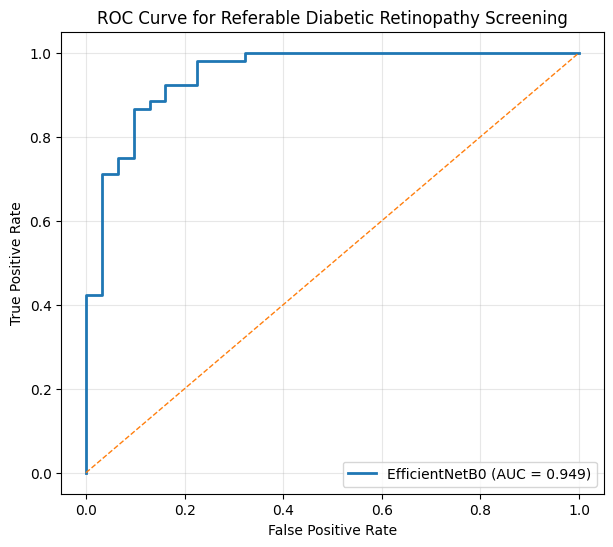

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_val_bin, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"EfficientNetB0 (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Referable Diabetic Retinopathy Screening")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

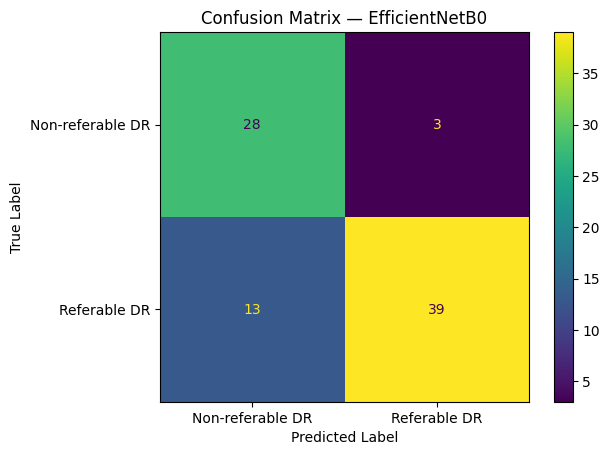

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-referable DR", "Referable DR"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — EfficientNetB0")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [70]:
# Find the last convolutional layer in EfficientNetB0

for layer in base_model_bin.layers:
    if len(layer.output.shape) == 4:
        last_conv_layer = layer

print("Last convolutional layer:")
print(last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

Last convolutional layer:
top_activation
Output shape: (None, 7, 7, 1280)


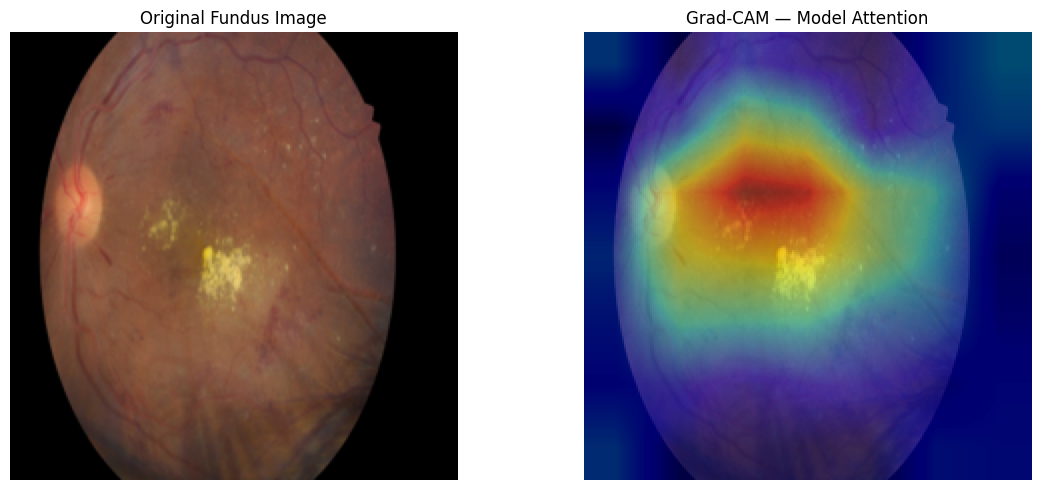

True label: Referable DR
Predicted probability: 0.7069


In [74]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Create a functional Grad-CAM model directly from EfficientNet
grad_model = tf.keras.models.Model(
    inputs=base_model_bin.input,
    outputs=[
        base_model_bin.get_layer(last_conv_layer.name).output,
        base_model_bin.output
    ]
)

# Select validation image
idx = 0

image = X_val_bin_255[idx]
input_image = np.expand_dims(image, axis=0).astype(np.float32)

# Calculate Grad-CAM
with tf.GradientTape() as tape:

    conv_output, features = grad_model(input_image, training=False)

    # Classification layer
    pooled = tf.reduce_mean(features, axis=(1, 2))
    dropout_output = binary_model.layers[-2](pooled, training=False)
    prediction = binary_model.layers[-1](dropout_output)

    loss = prediction[:, 0]

gradients = tape.gradient(loss, conv_output)

# Average gradients across spatial dimensions
weights = tf.reduce_mean(gradients, axis=(1, 2))

# Weighted combination
cam = tf.reduce_sum(
    weights[:, tf.newaxis, tf.newaxis, :] * conv_output,
    axis=-1
)

# Normalize
cam = tf.maximum(cam, 0)
cam = cam / (tf.reduce_max(cam) + 1e-8)

cam = cam[0].numpy()

# Resize heatmap to image size
cam_resized = tf.image.resize(
    cam[..., np.newaxis],
    (224, 224)
).numpy().squeeze()

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.astype(np.uint8))
plt.title("Original Fundus Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image.astype(np.uint8))
plt.imshow(
    cam_resized,
    cmap="jet",
    alpha=0.45
)
plt.title("Grad-CAM — Model Attention")
plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "True label:",
    "Referable DR" if y_val_bin[idx] == 1 else "Non-referable DR"
)

print("Predicted probability:", round(float(y_prob[idx]), 4))

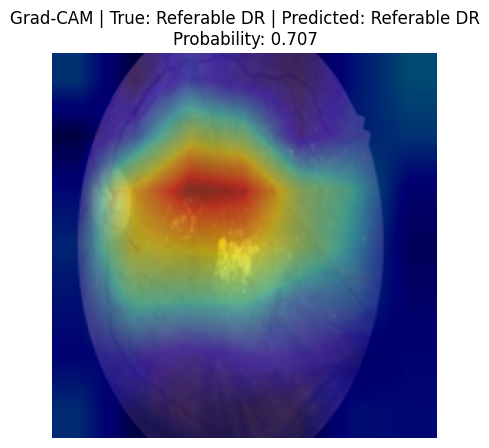

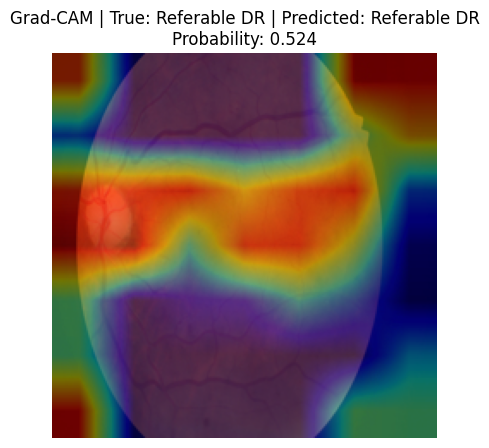

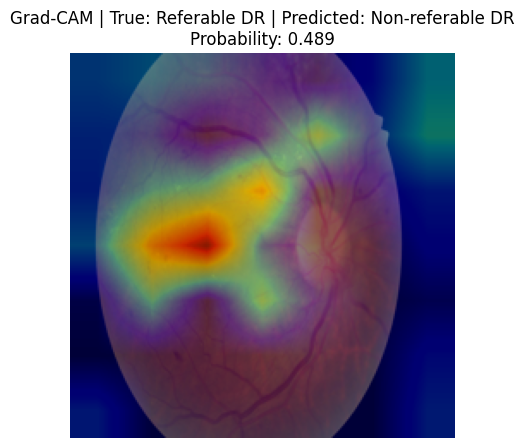

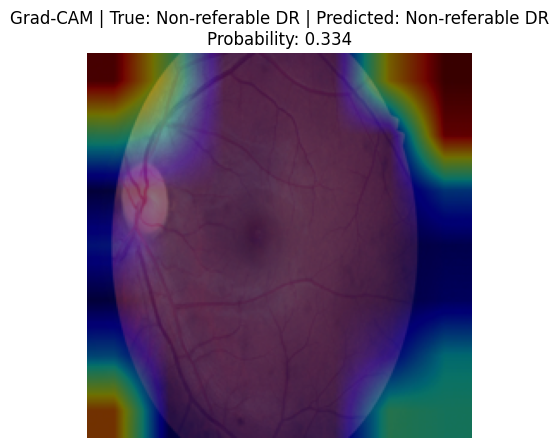

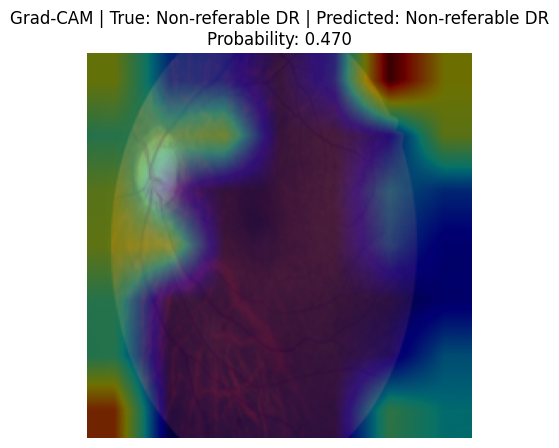

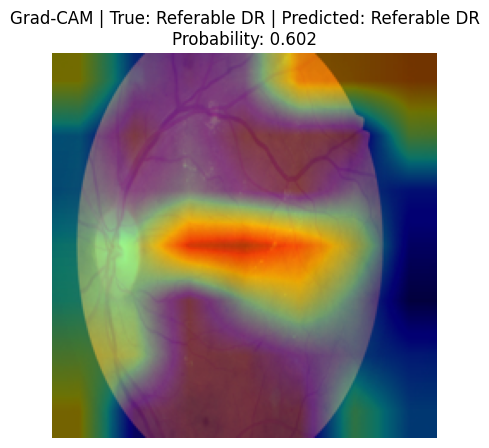

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

indices = [0, 10, 20, 30, 40, 50]

for idx in indices:

    image = X_val_bin_255[idx]
    input_image = np.expand_dims(image, axis=0).astype(np.float32)

    with tf.GradientTape() as tape:
        conv_output, features = grad_model(input_image, training=False)

        pooled = tf.reduce_mean(features, axis=(1, 2))
        dropout_output = binary_model.layers[-2](pooled, training=False)
        prediction = binary_model.layers[-1](dropout_output)

        loss = prediction[:, 0]

    gradients = tape.gradient(loss, conv_output)
    weights = tf.reduce_mean(gradients, axis=(1, 2))

    cam = tf.reduce_sum(
        weights[:, tf.newaxis, tf.newaxis, :] * conv_output,
        axis=-1
    )

    cam = tf.maximum(cam, 0)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    cam = tf.image.resize(
        cam[..., tf.newaxis],
        (224, 224)
    ).numpy()[0, :, :, 0]

    plt.figure(figsize=(6, 5))

    plt.imshow(image.astype(np.uint8))
    plt.imshow(cam, cmap="jet", alpha=0.45)

    true_label = (
        "Referable DR"
        if y_val_bin[idx] == 1
        else "Non-referable DR"
    )

    predicted_label = (
        "Referable DR"
        if y_prob[idx] >= 0.5
        else "Non-referable DR"
    )

    plt.title(
        f"Grad-CAM | True: {true_label} | "
        f"Predicted: {predicted_label}\n"
        f"Probability: {y_prob[idx]:.3f}"
    )

    plt.axis("off")
    plt.show()

In [104]:
# Find variables and functions related to the trained model / Grad-CAM

import gc

print("=== Possible model variables ===")
for name, obj in globals().items():
    if any(k in name.lower() for k in ["model", "grad", "cam", "checkpoint", "weight"]):
        print(name, "->", type(obj))

print("\n=== TensorFlow/Keras models currently in memory ===")
for obj in gc.get_objects():
    try:
        if hasattr(obj, "layers") and hasattr(obj, "predict"):
            print("Model found:", type(obj),
                  "| layers:", len(obj.layers))
    except:
        pass

=== Possible model variables ===


RuntimeError: dictionary changed size during iteration

In [76]:
import os

groundtruth_folder = "/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/2. Groundtruths"

print("Groundtruth files:\n")

for root, dirs, files in os.walk(groundtruth_folder):
    for file in files:
        print(os.path.join(root, file))

Groundtruth files:

/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv
/content/drive/MyDrive/DR_Project/B. Disease Grading/B. Disease Grading/2. Groundtruths/b. IDRiD_Disease Grading_Testing Labels.csv


In [77]:
import os

# Change this if your folder is somewhere else
seg_folder = "/content/drive/MyDrive/DR_Project/A. Segmentation"

for root, dirs, files in os.walk(seg_folder):
    level = root.replace(seg_folder, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

print("\n✅ Segmentation folder checked.")


✅ Segmentation folder checked.


In [78]:
import os

seg_folder = "/content/drive/MyDrive/DR_Project/A. Segmentation"

print("📁 Segmentation contents:\n")

for root, dirs, files in os.walk(seg_folder):
    print("\nFolder:", root)

    for file in files:
        print("  ", file)

📁 Segmentation contents:



In [80]:
import os

base = "/content/drive/MyDrive"

print("Searching for IDRiD / Segmentation folders...\n")

for root, dirs, files in os.walk(base):
    for d in dirs:
        name = d.lower()
        if "segmentation" in name or "idrid" in name:
            print(os.path.join(root, d))

Searching for IDRiD / Segmentation folders...



In [82]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/DR_Project/A. Segmentation.zip"
extract_path = "/content/drive/MyDrive/DR_Project/A_Segmentation"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ ZIP extracted successfully!")
print("\nExtracted contents:")

for item in os.listdir(extract_path):
    print("📁" if os.path.isdir(os.path.join(extract_path, item)) else "📄", item)

✅ ZIP extracted successfully!

Extracted contents:
📁 A. Segmentation


In [83]:
import os

seg_folder = "/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation"

print("Contents of A. Segmentation:\n")

for item in os.listdir(seg_folder):
    path = os.path.join(seg_folder, item)
    if os.path.isdir(path):
        print("📁 FOLDER:", item)
    else:
        print("📄 FILE:", item)


Contents of A. Segmentation:

📁 FOLDER: 1. Original Images
📁 FOLDER: 2. All Segmentation Groundtruths
📄 FILE: CC-BY-4.0.txt
📄 FILE: LICENSE.txt


In [84]:
import os

seg_folder = "/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation/2. All Segmentation Groundtruths"

print("Lesion groundtruth folders:\n")

for item in os.listdir(seg_folder):
    path = os.path.join(seg_folder, item)

    if os.path.isdir(path):
        print("📁 FOLDER:", item)
    else:
        print("📄 FILE:", item)

Lesion groundtruth folders:

📁 FOLDER: a. Training Set
📁 FOLDER: b. Testing Set


In [85]:
import os

train_folder = "/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set"

print("Training Set contents:\n")

for item in os.listdir(train_folder):
    path = os.path.join(train_folder, item)

    if os.path.isdir(path):
        print("📁 FOLDER:", item)
    else:
        print("📄 FILE:", item)

Training Set contents:

📁 FOLDER: 1. Microaneurysms
📁 FOLDER: 2. Haemorrhages
📁 FOLDER: 3. Hard Exudates
📁 FOLDER: 4. Soft Exudates
📁 FOLDER: 5. Optic Disc


In [86]:
import os

base = "/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms"

files = os.listdir(base)

print("Number of MA files:", len(files))
print("\nFirst 10 files:")

for f in files[:10]:
    print(f)

Number of MA files: 54

First 10 files:
IDRiD_01_MA.tif
IDRiD_02_MA.tif
IDRiD_03_MA.tif
IDRiD_04_MA.tif
IDRiD_05_MA.tif
IDRiD_06_MA.tif
IDRiD_07_MA.tif
IDRiD_08_MA.tif
IDRiD_09_MA.tif
IDRiD_10_MA.tif


In [87]:
import os

base = "/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set"

folders = [
    "1. Microaneurysms",
    "2. Haemorrhages",
    "3. Hard Exudates",
    "4. Soft Exudates",
    "5. Optic Disc"
]

for folder in folders:
    path = os.path.join(base, folder)
    files = [
        f for f in os.listdir(path)
        if f.lower().endswith((".tif", ".tiff", ".png"))
    ]

    print(f"\n{folder}")
    print("Number of masks:", len(files))
    print("First 5:", files[:5])


1. Microaneurysms
Number of masks: 54
First 5: ['IDRiD_01_MA.tif', 'IDRiD_02_MA.tif', 'IDRiD_03_MA.tif', 'IDRiD_04_MA.tif', 'IDRiD_05_MA.tif']

2. Haemorrhages
Number of masks: 53
First 5: ['IDRiD_01_HE.tif', 'IDRiD_02_HE.tif', 'IDRiD_03_HE.tif', 'IDRiD_04_HE.tif', 'IDRiD_05_HE.tif']

3. Hard Exudates
Number of masks: 54
First 5: ['IDRiD_01_EX.tif', 'IDRiD_02_EX.tif', 'IDRiD_03_EX.tif', 'IDRiD_04_EX.tif', 'IDRiD_05_EX.tif']

4. Soft Exudates
Number of masks: 26
First 5: ['IDRiD_03_SE.tif', 'IDRiD_08_SE.tif', 'IDRiD_13_SE.tif', 'IDRiD_14_SE.tif', 'IDRiD_17_SE.tif']

5. Optic Disc
Number of masks: 54
First 5: ['IDRiD_01_OD.tif', 'IDRiD_02_OD.tif', 'IDRiD_03_OD.tif', 'IDRiD_04_OD.tif', 'IDRiD_05_OD.tif']


In [88]:
from PIL import Image
import numpy as np
import os

mask_path = "/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms/IDRiD_01_MA.tif"

mask = Image.open(mask_path)
arr = np.array(mask)

print("Mask shape:", arr.shape)
print("Data type:", arr.dtype)
print("Minimum value:", arr.min())
print("Maximum value:", arr.max())
print("Unique values:", np.unique(arr)[:20])
print("Number of unique values:", len(np.unique(arr)))

Mask shape: (2848, 4288)
Data type: uint8
Minimum value: 0
Maximum value: 1
Unique values: [0 1]
Number of unique values: 2


In [90]:
import os

image_folder = "/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation/1. Original Images"

print("Original image files:\n")

files = os.listdir(image_folder)

print("Total files:", len(files))
print("\nFirst 20 files:")

for f in files[:20]:
    print(f)

Original image files:

Total files: 2

First 20 files:
a. Training Set
b. Testing Set


In [91]:
import os

image_folder = "/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation/1. Original Images/a. Training Set"

files = os.listdir(image_folder)

print("Total training images/files:", len(files))
print("\nFirst 20:")

for f in files[:20]:
    print(f)

Total training images/files: 54

First 20:
IDRiD_01.jpg
IDRiD_02.jpg
IDRiD_03.jpg
IDRiD_04.jpg
IDRiD_05.jpg
IDRiD_06.jpg
IDRiD_07.jpg
IDRiD_08.jpg
IDRiD_09.jpg
IDRiD_10.jpg
IDRiD_11.jpg
IDRiD_12.jpg
IDRiD_13.jpg
IDRiD_14.jpg
IDRiD_15.jpg
IDRiD_16.jpg
IDRiD_17.jpg
IDRiD_18.jpg
IDRiD_19.jpg
IDRiD_20.jpg


In [92]:
from PIL import Image
import os

# Change this to the actual Grad-CAM image you generated
gradcam_path = "/content/gradcam_result.png"

if os.path.exists(gradcam_path):
    img = Image.open(gradcam_path)

    print("Grad-CAM size:", img.size)
    print("Grad-CAM mode:", img.mode)

else:
    print("❌ Grad-CAM file not found at:")
    print(gradcam_path)
    print("\nLet's locate Grad-CAM files...")

    for root, dirs, files in os.walk("/content/drive/MyDrive/DR_Project"):
        for f in files:
            if "grad" in f.lower() and f.lower().endswith(
                (".png", ".jpg", ".jpeg", ".tif", ".tiff")
            ):
                print(os.path.join(root, f))

❌ Grad-CAM file not found at:
/content/gradcam_result.png

Let's locate Grad-CAM files...


In [93]:
import os

base = "/content/drive/MyDrive"

print("Searching entire Drive for Grad-CAM files...\n")

found = False

for root, dirs, files in os.walk(base):
    for f in files:
        name = f.lower()

        if "gradcam" in name or "grad-cam" in name or "grad_cam" in name:
            if name.endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff")):
                print(os.path.join(root, f))
                found = True

if not found:
    print("❌ No Grad-CAM image found in Google Drive.")

Searching entire Drive for Grad-CAM files...

❌ No Grad-CAM image found in Google Drive.


In [95]:
import os

base = "/content/drive/MyDrive"

print("Searching entire Drive for Grad-CAM files...\n")

found = False

for root, dirs, files in os.walk(base):
    for f in files:
        name = f.lower()

        if "gradcam" in name or "grad-cam" in name or "grad_cam" in name:
            if name.endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff")):
                print(os.path.join(root, f))
                found = True

if not found:
    print("❌ No Grad-CAM image found in Google Drive.")

Searching entire Drive for Grad-CAM files...

❌ No Grad-CAM image found in Google Drive.


In [101]:
import os

base = "/content/drive/MyDrive"

print("Searching entire Drive for Grad-CAM files...\n")

found = False

for root, dirs, files in os.walk(base):
    for f in files:
        name = f.lower()

        if "gradcam" in name or "grad-cam" in name or "grad_cam" in name:
            if name.endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff")):
                print(os.path.join(root, f))
                found = True

if not found:
    print("❌ No Grad-CAM image found in Google Drive.")

Searching entire Drive for Grad-CAM files...

❌ No Grad-CAM image found in Google Drive.


In [105]:
# Find variables and functions related to the trained model / Grad-CAM

import gc

print("=== Possible model variables ===")
for name, obj in globals().items():
    if any(k in name.lower() for k in ["model", "grad", "cam", "checkpoint", "weight"]):
        print(name, "->", type(obj))

print("\n=== TensorFlow/Keras models currently in memory ===")
for obj in gc.get_objects():
    try:
        if hasattr(obj, "layers") and hasattr(obj, "predict"):
            print("Model found:", type(obj),
                  "| layers:", len(obj.layers))
    except:
        pass

=== Possible model variables ===
grade_counts -> <class 'pandas.core.series.Series'>
compute_class_weight -> <class 'function'>
class_weights -> <class 'dict'>
grade -> <class 'int'>
weight -> <class 'numpy.float64'>
models -> <class 'module'>
base_model -> <class 'keras.src.models.functional.Functional'>
model -> <class 'keras.src.models.sequential.Sequential'>
base_model_bin -> <class 'keras.src.models.functional.Functional'>
binary_model -> <class 'keras.src.models.sequential.Sequential'>
make_gradcam -> <class 'function'>
grad_model -> <class 'keras.src.models.functional.Functional'>
gradients -> <class 'tensorflow.python.framework.ops.EagerTensor'>
weights -> <class 'tensorflow.python.framework.ops.EagerTensor'>
cam -> <class 'numpy.ndarray'>
cam_resized -> <class 'numpy.ndarray'>
gradcam_path -> <class 'str'>

=== TensorFlow/Keras models currently in memory ===
Model found: <class '_pydevd_bundle.pydevd_constants.Null'> | layers: 0
Model found: <class 'unittest.mock._Call'> | lay

/tmp/ipykernel_2486/2886272970.py:13: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if hasattr(obj, "layers") and hasattr(obj, "predict"):


Model found: <class 'keras.src.models.sequential.Sequential'> | layers: 4
Model found: <class 'keras.src.models.functional.Functional'> | layers: 238
Model found: <class 'keras.src.models.sequential.Sequential'> | layers: 5
Model found: <class 'keras.src.models.functional.Functional'> | layers: 5
Model found: <class 'keras.src.models.functional.Functional'> | layers: 6
Model found: <class 'keras.src.models.functional.Functional'> | layers: 238
Model found: <class 'keras.src.models.sequential.Sequential'> | layers: 5
Model found: <class 'keras.src.models.functional.Functional'> | layers: 6
Model found: <class 'keras.src.models.functional.Functional'> | layers: 238


In [106]:
import inspect

print("========== make_gradcam() ==========")
print(inspect.getsource(make_gradcam))

print("\n========== grad_model ==========")
print("Input:", grad_model.input)
print("Outputs:", grad_model.output)

print("\n========== binary_model ==========")
print("Input shape:", binary_model.input_shape)
print("Output shape:", binary_model.output_shape)

print("\n========== model ==========")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

========== make_gradcam() ==========
def make_gradcam(model, image, conv_layer):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, prediction = grad_model(image)
        loss = prediction[:, 0]

    gradients = tape.gradient(loss, conv_output)

    weights = tf.reduce_mean(gradients, axis=(1, 2))

    cam = tf.reduce_sum(
        weights[:, tf.newaxis, tf.newaxis, :] * conv_output,
        axis=-1
    )

    cam = tf.maximum(cam, 0)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    return cam[0].numpy()


========== grad_model ==========
Input: <KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_492>
Outputs: [<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_729>, <KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_te

In [107]:
print("=== binary_model layers ===")
for i, layer in enumerate(binary_model.layers):
    print(i, layer.name, type(layer).__name__, layer.output.shape)

print("\n=== Last layers of base_model_bin ===")
for i, layer in enumerate(base_model_bin.layers[-10:]):
    print(
        len(base_model_bin.layers)-10+i,
        layer.name,
        type(layer).__name__,
        layer.output.shape
    )

print("\n=== Current grad_model ===")
print("Number of outputs:", len(grad_model.outputs))
for i, output in enumerate(grad_model.outputs):
    print(i, output.shape)

=== binary_model layers ===
0 sequential_1 Sequential (None, 224, 224, 3)
1 efficientnetb0 Functional (None, 7, 7, 1280)
2 global_average_pooling2d_2 GlobalAveragePooling2D (None, 1280)
3 dropout_2 Dropout (None, 1280)
4 dense_2 Dense (None, 1)

=== Last layers of base_model_bin ===
228 block7a_se_squeeze GlobalAveragePooling2D (None, 1152)
229 block7a_se_reshape Reshape (None, 1, 1, 1152)
230 block7a_se_reduce Conv2D (None, 1, 1, 48)
231 block7a_se_expand Conv2D (None, 1, 1, 1152)
232 block7a_se_excite Multiply (None, 7, 7, 1152)
233 block7a_project_conv Conv2D (None, 7, 7, 320)
234 block7a_project_bn BatchNormalization (None, 7, 7, 320)
235 top_conv Conv2D (None, 7, 7, 1280)
236 top_bn BatchNormalization (None, 7, 7, 1280)
237 top_activation Activation (None, 7, 7, 1280)

=== Current grad_model ===
Number of outputs: 2
0 (None, 7, 7, 1280)
1 (None, 7, 7, 1280)


In [108]:
# Check the exact EfficientNetB0 inside the binary classifier

efficientnet = binary_model.get_layer("efficientnetb0")

print("EfficientNet input:", efficientnet.input.shape)
print("EfficientNet output:", efficientnet.output.shape)

print("\nTarget Grad-CAM layer:")
target_layer = efficientnet.get_layer("top_activation")
print("Name:", target_layer.name)
print("Output:", target_layer.output.shape)

print("\nBinary classifier:")
print("binary_model input :", binary_model.input.shape)
print("binary_model output:", binary_model.output.shape)

print("\nBinary classifier final layer:")
print(binary_model.layers[-1].name)
print(binary_model.layers[-1].output.shape)

EfficientNet input: (None, 224, 224, 3)
EfficientNet output: (None, 7, 7, 1280)

Target Grad-CAM layer:
Name: top_activation
Output: (None, 7, 7, 1280)

Binary classifier:


AttributeError: The layer sequential_3 has never been called and thus has no defined input.

In [109]:
# Check the binary model by using the model directly

print("binary_model type:", type(binary_model))
print("binary_model layers:", len(binary_model.layers))

print("\nFinal layer:")
print(binary_model.layers[-1])
print("Final layer type:", type(binary_model.layers[-1]).__name__)

print("\nEfficientNet output:")
print(efficientnet.output.shape)

print("\nTarget layer:")
print(target_layer.name)
print(target_layer.output.shape)

# Check whether the model can make a prediction
print("\nTesting model prediction...")

import numpy as np

dummy_image = np.zeros((1, 224, 224, 3), dtype=np.float32)
dummy_prediction = binary_model(dummy_image, training=False)

print("Prediction shape:", dummy_prediction.shape)
print("Prediction value:", dummy_prediction.numpy())

binary_model type: <class 'keras.src.models.sequential.Sequential'>
binary_model layers: 5

Final layer:
<Dense name=dense_2, built=True>
Final layer type: Dense

EfficientNet output:
(None, 7, 7, 1280)

Target layer:
top_activation
(None, 7, 7, 1280)

Testing model prediction...
Prediction shape: (1, 1)
Prediction value: [[0.52702814]]


In [110]:
# Create the correct Grad-CAM model
# EfficientNetB0 -> top_activation -> binary prediction

import tensorflow as tf

grad_model_correct = tf.keras.models.Model(
    inputs=efficientnet.input,
    outputs=[
        target_layer.output,
        binary_model(efficientnet.output, training=False)
    ]
)

print("Grad-CAM model created successfully.")

print("\nInputs:")
print(grad_model_correct.inputs)

print("\nOutputs:")
for i, output in enumerate(grad_model_correct.outputs):
    print(i, output.shape)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'input_layer_6' of layer 'functional_3' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 7, 7, 1280)[0m

Arguments received by Sequential.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_729>',)
  • kwargs={'training': 'False', 'mask': 'None'}

In [111]:
import tensorflow as tf

# Get the layers after EfficientNetB0
gap_layer = binary_model.layers[2]
dropout_layer = binary_model.layers[3]
dense_layer = binary_model.layers[4]

# Build Grad-CAM model directly from EfficientNetB0
grad_model_correct = tf.keras.models.Model(
    inputs=efficientnet.input,
    outputs=[
        target_layer.output,
        dense_layer(
            dropout_layer(
                gap_layer(target_layer.output),
                training=False
            ),
            training=False
        )
    ]
)

print("✅ Correct Grad-CAM model created")

print("\nInput:")
print(grad_model_correct.input.shape)

print("\nOutputs:")
for i, output in enumerate(grad_model_correct.outputs):
    print(i, output.shape)

✅ Correct Grad-CAM model created

Input:
(None, 224, 224, 3)

Outputs:
0 (None, 7, 7, 1280)
1 (None, 1)


In [112]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image

# IDRiD image
image_path = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set/IDRiD_01.jpg"
)

# Load and resize exactly as the model expects
img = Image.open(image_path).convert("RGB")
img_224 = img.resize((224, 224))

image_array = np.array(img_224).astype(np.float32) / 255.0
image_input = np.expand_dims(image_array, axis=0)

# Calculate Grad-CAM
with tf.GradientTape() as tape:
    conv_output, prediction = grad_model_correct(image_input, training=False)
    loss = prediction[:, 0]

gradients = tape.gradient(loss, conv_output)

weights = tf.reduce_mean(gradients, axis=(1, 2))

cam = tf.reduce_sum(
    weights[:, tf.newaxis, tf.newaxis, :] * conv_output,
    axis=-1
)

cam = tf.maximum(cam, 0)
cam = cam / (tf.reduce_max(cam) + 1e-8)

cam = cam[0].numpy()

print("✅ Grad-CAM generated")
print("Original image size:", img.size)
print("Model input size:", image_input.shape)
print("CAM shape:", cam.shape)
print("CAM min:", cam.min())
print("CAM max:", cam.max())
print("Prediction:", float(prediction.numpy()[0, 0]))

✅ Grad-CAM generated
Original image size: (4288, 2848)
Model input size: (1, 224, 224, 3)
CAM shape: (7, 7)
CAM min: 0.0
CAM max: 0.99999666
Prediction: 0.5258457064628601


In [113]:
import cv2
import os
import numpy as np

# Original IDRiD dimensions: width=4288, height=2848
original_width = 4288
original_height = 2848

# Resize Grad-CAM to the exact original image dimensions
cam_original = cv2.resize(
    cam,
    (original_width, original_height),
    interpolation=cv2.INTER_LINEAR
)

# Normalize again after resizing
cam_original = cam_original - cam_original.min()
cam_original = cam_original / (cam_original.max() + 1e-8)

# Save numerical CAM
save_path = (
    "/content/drive/MyDrive/DR_Project/"
    "GradCAM_IDRiD_01.npy"
)

np.save(save_path, cam_original)

print("✅ Grad-CAM resized and saved")
print("CAM shape:", cam_original.shape)
print("CAM min:", cam_original.min())
print("CAM max:", cam_original.max())
print("Saved to:", save_path)


✅ Grad-CAM resized and saved
CAM shape: (2848, 4288)
CAM min: 0.0
CAM max: 1.0
Saved to: /content/drive/MyDrive/DR_Project/GradCAM_IDRiD_01.npy


In [114]:
from PIL import Image
import numpy as np
import os

base = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "2. All Segmentation Groundtruths/"
    "a. Training Set"
)

mask_paths = {
    "MA": os.path.join(base, "1. Microaneurysms", "IDRiD_01_MA.tif"),
    "HE": os.path.join(base, "2. Haemorrhages", "IDRiD_01_HE.tif"),
    "EX": os.path.join(base, "3. Hard Exudates", "IDRiD_01_EX.tif"),
    "SE": os.path.join(base, "4. Soft Exudates", "IDRiD_01_SE.tif"),
}

for lesion, path in mask_paths.items():
    if os.path.exists(path):
        mask = np.array(Image.open(path))
        print(f"✅ {lesion}: shape={mask.shape}, dtype={mask.dtype}, "
              f"unique={np.unique(mask)}, pixels={np.sum(mask > 0)}")
    else:
        print(f"⚠️ {lesion}: mask not present")

✅ MA: shape=(2848, 4288), dtype=uint8, unique=[0 1], pixels=6941
✅ HE: shape=(2848, 4288), dtype=uint8, unique=[0 1], pixels=35430
✅ EX: shape=(2848, 4288), dtype=uint8, unique=[0 1], pixels=113286
⚠️ SE: mask not present


In [116]:
import numpy as np

# Load the saved full-resolution Grad-CAM
cam_original = np.load(
    "/content/drive/MyDrive/DR_Project/GradCAM_IDRiD_01.npy"
)

# Convert Grad-CAM to binary attention mask
cam_binary = cam_original >= 0.5

print("Grad-CAM shape:", cam_original.shape)
print("Active CAM pixels:", np.sum(cam_binary))

def calculate_metrics(cam_mask, lesion_mask):
    cam_mask = cam_mask.astype(bool)
    lesion_mask = lesion_mask.astype(bool)

    intersection = np.logical_and(cam_mask, lesion_mask).sum()
    union = np.logical_or(cam_mask, lesion_mask).sum()

    cam_pixels = cam_mask.sum()
    lesion_pixels = lesion_mask.sum()

    # IoU
    iou = intersection / union if union > 0 else 0.0

    # Dice
    dice = (
        2 * intersection / (cam_pixels + lesion_pixels)
        if (cam_pixels + lesion_pixels) > 0
        else 0.0
    )

    # Lesion coverage / recall
    coverage = (
        intersection / lesion_pixels
        if lesion_pixels > 0
        else 0.0
    )

    return iou, dice, coverage, intersection


# Load masks
from PIL import Image
import os

base = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "2. All Segmentation Groundtruths/"
    "a. Training Set"
)

results = {}

for lesion, folder, suffix in [
    ("MA", "1. Microaneurysms", "MA"),
    ("HE", "2. Haemorrhages", "HE"),
    ("EX", "3. Hard Exudates", "EX"),
]:

    path = os.path.join(
        base,
        folder,
        f"IDRiD_01_{suffix}.tif"
    )

    lesion_mask = np.array(Image.open(path)) > 0

    iou, dice, coverage, intersection = calculate_metrics(
        cam_binary,
        lesion_mask
    )

    results[lesion] = {
        "IoU": iou,
        "Dice": dice,
        "Coverage": coverage,
        "Intersection_pixels": intersection
    }

print("\n========== Grad-CAM vs Lesions ==========")

for lesion, r in results.items():
    print(f"\n{lesion}")
    print(f"IoU:      {r['IoU']:.4f}")
    print(f"Dice:     {r['Dice']:.4f}")
    print(f"Coverage: {r['Coverage']:.4f}")
    print(f"Overlap pixels: {r['Intersection_pixels']}")


Grad-CAM shape: (2848, 4288)
Active CAM pixels: 2536032

========== Grad-CAM vs Lesions ==========

MA
IoU:      0.0002
Dice:     0.0005
Coverage: 0.0880
Overlap pixels: 611

HE
IoU:      0.0025
Dice:     0.0049
Coverage: 0.1785
Overlap pixels: 6325

EX
IoU:      0.0000
Dice:     0.0000
Coverage: 0.0000
Overlap pixels: 0


In [117]:
from PIL import Image
import numpy as np
import cv2

# Load original image
image_path = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set/IDRiD_01.jpg"
)

img = np.array(Image.open(image_path).convert("RGB"))

# Create a retinal-field mask from image brightness
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Pixels brighter than a small threshold represent the retinal field
retina_mask = gray > 10

# Remove tiny isolated regions
retina_mask = retina_mask.astype(np.uint8)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    retina_mask, connectivity=8
)

# Keep the largest connected component
if num_labels > 1:
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    retina_mask = (labels == largest_label)

# CAM threshold
cam_binary = cam_original >= 0.5

# CAM activation inside retinal field
cam_inside_retina = np.logical_and(
    cam_binary,
    retina_mask
)

print("Original image:", img.shape)
print("Retinal field pixels:", retina_mask.sum())
print("CAM active pixels:", cam_binary.sum())
print("CAM inside retinal field:", cam_inside_retina.sum())

print(
    "Percentage of CAM inside retina:",
    f"{100 * cam_inside_retina.sum() / cam_binary.sum():.2f}%"
)

Original image: (2848, 4288, 3)
Retinal field pixels: 8523357
CAM active pixels: 2536032
CAM inside retinal field: 1372745
Percentage of CAM inside retina: 54.13%


In [118]:
# Restrict Grad-CAM to the retinal field
cam_retina = np.logical_and(
    cam_original >= 0.5,
    retina_mask
)

print("Retinal-restricted CAM pixels:", cam_retina.sum())

def calculate_metrics(cam_mask, lesion_mask):
    cam_mask = cam_mask.astype(bool)
    lesion_mask = lesion_mask.astype(bool)

    intersection = np.logical_and(cam_mask, lesion_mask).sum()
    union = np.logical_or(cam_mask, lesion_mask).sum()

    cam_pixels = cam_mask.sum()
    lesion_pixels = lesion_mask.sum()

    iou = intersection / union if union > 0 else 0.0

    dice = (
        2 * intersection / (cam_pixels + lesion_pixels)
        if (cam_pixels + lesion_pixels) > 0
        else 0.0
    )

    coverage = (
        intersection / lesion_pixels
        if lesion_pixels > 0
        else 0.0
    )

    return iou, dice, coverage, intersection


print("\n========== Retinal-restricted Grad-CAM ==========")

for lesion, folder, suffix in [
    ("MA", "1. Microaneurysms", "MA"),
    ("HE", "2. Haemorrhages", "HE"),
    ("EX", "3. Hard Exudates", "EX"),
]:

    path = os.path.join(
        base,
        folder,
        f"IDRiD_01_{suffix}.tif"
    )

    lesion_mask = np.array(Image.open(path)) > 0

    iou, dice, coverage, intersection = calculate_metrics(
        cam_retina,
        lesion_mask
    )

    print(f"\n{lesion}")
    print(f"IoU:              {iou:.6f}")
    print(f"Dice:             {dice:.6f}")
    print(f"Lesion coverage:  {coverage:.6f}")
    print(f"Overlap pixels:   {intersection}")

Retinal-restricted CAM pixels: 1372745

========== Retinal-restricted Grad-CAM ==========

MA
IoU:              0.000443
Dice:             0.000886
Lesion coverage:  0.088028
Overlap pixels:   611

HE
IoU:              0.004512
Dice:             0.008983
Lesion coverage:  0.178521
Overlap pixels:   6325

EX
IoU:              0.000000
Dice:             0.000000
Lesion coverage:  0.000000
Overlap pixels:   0


In [119]:
import pandas as pd
import os

csv_path = (
    "/content/drive/MyDrive/DR_Project/"
    "B. Disease Grading/B. Disease Grading/"
    "2. Groundtruths/"
    "a. IDRiD_Disease Grading_Training Labels.csv"
)

df = pd.read_csv(csv_path)

print("CSV shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

CSV shape: (413, 12)

Column names:
['Image name', 'Retinopathy grade', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

First 10 rows:


,Image name,Retinopathy grade,Risk of macular edema,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,IDRiD_001,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDRiD_002,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IDRiD_003,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IDRiD_004,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IDRiD_005,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,IDRiD_006,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,IDRiD_007,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,IDRiD_008,4,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,IDRiD_009,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,IDRiD_010,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
# Clean and inspect the official IDRiD training labels

labels = df[["Image name", "Retinopathy grade"]].copy()

labels["Retinopathy grade"] = pd.to_numeric(
    labels["Retinopathy grade"],
    errors="coerce"
)

print("Total labelled images:", len(labels))
print("\nRetinopathy grade distribution:")
print(labels["Retinopathy grade"].value_counts().sort_index())

print("\nGrade percentages:")
print(
    (labels["Retinopathy grade"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

Total labelled images: 413

Retinopathy grade distribution:
Retinopathy grade
0    134
1     20
2    136
3     74
4     49
Name: count, dtype: int64

Grade percentages:
Retinopathy grade
0    32.45
1     4.84
2    32.93
3    17.92
4    11.86
Name: proportion, dtype: float64


In [121]:
import os

seg_base = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "2. All Segmentation Groundtruths/"
    "a. Training Set"
)

lesion_folders = {
    "MA": "1. Microaneurysms",
    "HE": "2. Haemorrhages",
    "EX": "3. Hard Exudates",
    "SE": "4. Soft Exudates",
    "OD": "5. Optic Disc"
}

print("========== Available training masks ==========")

for lesion, folder in lesion_folders.items():
    path = os.path.join(seg_base, folder)

    files = [
        f for f in os.listdir(path)
        if f.lower().endswith(".tif")
    ]

    print(f"{lesion}: {len(files)} masks")

========== Available training masks ==========
MA: 54 masks
HE: 53 masks
EX: 54 masks
SE: 26 masks
OD: 54 masks


In [122]:
import os
import re
import pandas as pd

# Training image directory
image_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set"
)

# Get actual image IDs
image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

image_ids = sorted([
    os.path.splitext(f)[0]
    for f in image_files
])

# Create a matching table
matching_rows = []

for image_id in image_ids:
    # IDRiD_01 -> IDRiD_001
    match = re.search(r"(\d+)$", image_id)

    if not match:
        continue

    number = int(match.group(1))

    csv_id = f"IDRiD_{number:03d}"

    label_row = labels[
        labels["Image name"] == csv_id
    ]

    if len(label_row) == 0:
        continue

    grade = int(label_row.iloc[0]["Retinopathy grade"])

    row = {
        "Image_ID": image_id,
        "CSV_ID": csv_id,
        "Grade": grade,
    }

    # Check each lesion annotation
    for lesion, folder, suffix in [
        ("MA", "1. Microaneurysms", "MA"),
        ("HE", "2. Haemorrhages", "HE"),
        ("EX", "3. Hard Exudates", "EX"),
        ("SE", "4. Soft Exudates", "SE"),
        ("OD", "5. Optic Disc", "OD"),
    ]:
        mask_path = os.path.join(
            seg_base,
            folder,
            f"{image_id}_{suffix}.tif"
        )

        row[f"{lesion}_available"] = os.path.exists(mask_path)

    matching_rows.append(row)

matching_df = pd.DataFrame(matching_rows)

print("Total matched images:", len(matching_df))

print("\nFirst 10 matches:")
display(matching_df.head(10))

print("\nMask availability:")
for lesion in ["MA", "HE", "EX", "SE", "OD"]:
    print(
        f"{lesion}:",
        matching_df[f"{lesion}_available"].sum()
    )

print("\nGrade distribution of matched images:")
print(
    matching_df["Grade"]
    .value_counts()
    .sort_index()
)

Total matched images: 54

First 10 matches:


,Image_ID,CSV_ID,Grade,MA_available,HE_available,EX_available,SE_available,OD_available
0,IDRiD_01,IDRiD_001,3,True,True,True,False,True
1,IDRiD_02,IDRiD_002,3,True,True,True,False,True
2,IDRiD_03,IDRiD_003,2,True,True,True,True,True
3,IDRiD_04,IDRiD_004,3,True,True,True,False,True
4,IDRiD_05,IDRiD_005,4,True,True,True,False,True
5,IDRiD_06,IDRiD_006,4,True,True,True,False,True
6,IDRiD_07,IDRiD_007,4,True,True,True,False,True
7,IDRiD_08,IDRiD_008,4,True,True,True,True,True
8,IDRiD_09,IDRiD_009,3,True,True,True,False,True
9,IDRiD_10,IDRiD_010,4,True,True,True,False,True



Mask availability:
MA: 54
HE: 53
EX: 54
SE: 26
OD: 54

Grade distribution of matched images:
Grade
1     1
2    18
3    16
4    19
Name: count, dtype: int64


In [123]:
import os
import numpy as np
import cv2
from PIL import Image
import tensorflow as tf

# Output directory
gradcam_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "GradCAM_IDRiD_Training"
)

os.makedirs(gradcam_dir, exist_ok=True)

# Image directory
image_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set"
)

print("Generating Grad-CAM for 54 training images...")
print("=" * 50)

results = []

for i, image_id in enumerate(image_ids, 1):

    image_path = os.path.join(
        image_dir,
        image_id + ".jpg"
    )

    # Load original image
    original = Image.open(image_path).convert("RGB")
    original_np = np.array(original)

    h, w = original_np.shape[:2]

    # Resize for model
    img_224 = cv2.resize(
        original_np,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    img_input = img_224.astype(np.float32) / 255.0
    img_input = np.expand_dims(img_input, axis=0)

    # Grad-CAM
    with tf.GradientTape() as tape:

        conv_output, prediction = grad_model_correct(
            img_input,
            training=False
        )

        loss = prediction[:, 0]

    gradients = tape.gradient(
        loss,
        conv_output
    )

    weights = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    cam = tf.reduce_sum(
        weights[:, tf.newaxis, tf.newaxis, :] *
        conv_output,
        axis=-1
    )

    cam = tf.maximum(cam, 0)

    cam = cam / (
        tf.reduce_max(cam) + 1e-8
    )

    cam = cam[0].numpy()

    # Resize CAM back to original image size
    cam_original = cv2.resize(
        cam,
        (w, h),
        interpolation=cv2.INTER_LINEAR
    )

    # Normalize again
    cam_original = (
        cam_original - cam_original.min()
    )

    cam_original = (
        cam_original /
        (cam_original.max() + 1e-8)
    )

    # Save CAM
    save_path = os.path.join(
        gradcam_dir,
        image_id + "_GradCAM.npy"
    )

    np.save(
        save_path,
        cam_original.astype(np.float32)
    )

    results.append({
        "Image_ID": image_id,
        "Prediction": float(prediction[0, 0].numpy()),
        "CAM_shape": cam_original.shape,
        "CAM_path": save_path
    })

    if i % 10 == 0 or i == 54:
        print(
            f"{i}/54 completed | "
            f"{image_id} | "
            f"Prediction = {float(prediction[0,0]):.4f}"
        )

print("=" * 50)
print("DONE.")
print("Grad-CAM files saved to:")
print(gradcam_dir)

gradcam_df = pd.DataFrame(results)

print("\nGenerated files:", len(gradcam_df))
display(gradcam_df.head())

Generating Grad-CAM for 54 training images...
10/54 completed | IDRiD_10 | Prediction = 0.5259
20/54 completed | IDRiD_20 | Prediction = 0.5258
30/54 completed | IDRiD_30 | Prediction = 0.5260
40/54 completed | IDRiD_40 | Prediction = 0.5256
50/54 completed | IDRiD_50 | Prediction = 0.5262
54/54 completed | IDRiD_54 | Prediction = 0.5259
DONE.
Grad-CAM files saved to:
/content/drive/MyDrive/DR_Project/GradCAM_IDRiD_Training

Generated files: 54


,Image_ID,Prediction,CAM_shape,CAM_path
0,IDRiD_01,0.525840,"(2848, 4288)",/content/drive/MyDrive/DR_Project/GradCAM_IDRi...
1,IDRiD_02,0.526188,"(2848, 4288)",/content/drive/MyDrive/DR_Project/GradCAM_IDRi...
2,IDRiD_03,0.525892,"(2848, 4288)",/content/drive/MyDrive/DR_Project/GradCAM_IDRi...
3,IDRiD_04,0.526098,"(2848, 4288)",/content/drive/MyDrive/DR_Project/GradCAM_IDRi...
4,IDRiD_05,0.526011,"(2848, 4288)",/content/drive/MyDrive/DR_Project/GradCAM_IDRi...


In [124]:
import os
import numpy as np

print("========== Grad-CAM Verification ==========")

files = sorted([
    f for f in os.listdir(gradcam_dir)
    if f.endswith("_GradCAM.npy")
])

print("Total Grad-CAM files:", len(files))

# Check first 5 files
print("\nFirst 5 files:")
for f in files[:5]:
    cam = np.load(os.path.join(gradcam_dir, f))

    print(
        f"{f} | "
        f"shape={cam.shape} | "
        f"min={cam.min():.4f} | "
        f"max={cam.max():.4f} | "
        f"mean={cam.mean():.4f} | "
        f"std={cam.std():.4f}"
    )

# Check whether CAMs are actually different
cam_means = []
cam_stds = []

for f in files:
    cam = np.load(os.path.join(gradcam_dir, f))
    cam_means.append(cam.mean())
    cam_stds.append(cam.std())

print("\n========== Overall CAM Statistics ==========")
print("Mean of CAM means:", np.mean(cam_means))
print("Mean of CAM stds :", np.mean(cam_stds))
print("Minimum CAM std  :", np.min(cam_stds))
print("Maximum CAM std  :", np.max(cam_stds))

# Compare first and second CAM
if len(files) >= 2:
    cam1 = np.load(os.path.join(gradcam_dir, files[0]))
    cam2 = np.load(os.path.join(gradcam_dir, files[1]))

    difference = np.mean(np.abs(cam1 - cam2))

    print("\nMean absolute difference between")
    print(files[0], "and", files[1], "=", difference)

print("\nVerification complete.")

========== Grad-CAM Verification ==========
Total Grad-CAM files: 54

First 5 files:
IDRiD_01_GradCAM.npy | shape=(2848, 4288) | min=0.0000 | max=1.0000 | mean=0.3283 | std=0.2148
IDRiD_02_GradCAM.npy | shape=(2848, 4288) | min=0.0000 | max=1.0000 | mean=0.3300 | std=0.2145
IDRiD_03_GradCAM.npy | shape=(2848, 4288) | min=0.0000 | max=1.0000 | mean=0.3285 | std=0.2147
IDRiD_04_GradCAM.npy | shape=(2848, 4288) | min=0.0000 | max=1.0000 | mean=0.3301 | std=0.2144
IDRiD_05_GradCAM.npy | shape=(2848, 4288) | min=0.0000 | max=1.0000 | mean=0.3292 | std=0.2148

========== Overall CAM Statistics ==========
Mean of CAM means: 0.32899156
Mean of CAM stds : 0.21475492
Minimum CAM std  : 0.2143256
Maximum CAM std  : 0.21528545

Mean absolute difference between
IDRiD_01_GradCAM.npy and IDRiD_02_GradCAM.npy = 0.0021934323

Verification complete.


In [125]:
print("========== Model Prediction Check ==========")

prediction_check = []

for image_id in image_ids:

    image_path = os.path.join(
        image_dir,
        image_id + ".jpg"
    )

    original = Image.open(image_path).convert("RGB")

    img = np.array(original)

    img = cv2.resize(
        img,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = binary_model.predict(
        img,
        verbose=0
    )[0][0]

    prediction_check.append({
        "Image_ID": image_id,
        "Prediction": float(pred)
    })

prediction_check_df = pd.DataFrame(prediction_check)

print("\nPrediction summary:")
print(prediction_check_df["Prediction"].describe())

print("\nFirst 10 predictions:")
display(prediction_check_df.head(10))

print("\nMinimum prediction:",
      prediction_check_df["Prediction"].min())

print("Maximum prediction:",
      prediction_check_df["Prediction"].max())

print("Standard deviation:",
      prediction_check_df["Prediction"].std())

========== Model Prediction Check ==========

Prediction summary:
count    54.000000
mean      0.525976
std       0.000173
min       0.525517
25%       0.525876
50%       0.525999
75%       0.526094
max       0.526299
Name: Prediction, dtype: float64

First 10 predictions:


,Image_ID,Prediction
0,IDRiD_01,0.525840
1,IDRiD_02,0.526188
2,IDRiD_03,0.525892
3,IDRiD_04,0.526098
4,IDRiD_05,0.526011
5,IDRiD_06,0.526254
6,IDRiD_07,0.526010
7,IDRiD_08,0.525984
8,IDRiD_09,0.526049
9,IDRiD_10,0.525950



Minimum prediction: 0.5255170464515686
Maximum prediction: 0.5262992978096008
Standard deviation: 0.00017346603873267296


In [126]:
import os

project_root = "/content/drive/MyDrive/DR_Project"

model_files = []

for root, dirs, files in os.walk(project_root):
    for f in files:
        if f.lower().endswith((
            ".h5",
            ".keras",
            ".hdf5",
            ".weights.h5"
        )):
            model_files.append(
                os.path.join(root, f)
            )

print("========== MODEL FILES FOUND ==========")
print("Total:", len(model_files))

for path in model_files:
    print(path)

========== MODEL FILES FOUND ==========
Total: 0


In [127]:
print("========== CURRENT MODEL WEIGHT CHECK ==========")

print("binary_model:")
print("Number of layers:", len(binary_model.layers))

print("\nTrainable parameters:",
      binary_model.count_params())

print("\nLast Dense layer weights:")

dense_weights = binary_model.layers[-1].get_weights()

if len(dense_weights) == 2:
    print("Kernel shape:", dense_weights[0].shape)
    print("Bias shape:", dense_weights[1].shape)

    print("\nKernel statistics:")
    print("Mean:", dense_weights[0].mean())
    print("Std :", dense_weights[0].std())
    print("Min :", dense_weights[0].min())
    print("Max :", dense_weights[0].max())

    print("\nBias:")
    print(dense_weights[1])

else:
    print("WARNING: Dense layer has no weights!")

print("\nModel summary:")
binary_model.summary()

========== CURRENT MODEL WEIGHT CHECK ==========
binary_model:
Number of layers: 5

Trainable parameters: 4050852

Last Dense layer weights:
Kernel shape: (1280, 1)
Bias shape: (1,)

Kernel statistics:
Mean: 0.00019671416
Std : 0.040401895
Min : -0.089169234
Max : 0.09514725

Bias:
[-0.00045703]

Model summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,416 (15.46 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2,564 (10.02 KB)

In [128]:
import numpy as np
import os
import cv2
from PIL import Image

print("========== FEATURE VARIATION CHECK ==========")

efficientnet = binary_model.get_layer("efficientnetb0")

feature_model = tf.keras.models.Model(
    inputs=efficientnet.input,
    outputs=efficientnet.output
)

features = []

for image_id in image_ids:

    image_path = os.path.join(
        image_dir,
        image_id + ".jpg"
    )

    img = np.array(
        Image.open(image_path).convert("RGB")
    )

    img = cv2.resize(
        img,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    feature = feature_model(
        img,
        training=False
    ).numpy()[0]

    features.append(feature)

features = np.array(features)

print("Feature array shape:", features.shape)

print("\nFeature statistics:")
print("Mean:", features.mean())
print("Std :", features.std())
print("Min :", features.min())
print("Max :", features.max())

# Compare features between first two images
feature_difference = np.mean(
    np.abs(features[0] - features[1])
)

print("\nMean absolute feature difference")
print("IDRiD_01 vs IDRiD_02:", feature_difference)

# Variation across the 54 images
per_feature_std = np.std(features, axis=0)

print("\nMean feature-wise std:",
      per_feature_std.mean())

print("Maximum feature-wise std:",
      per_feature_std.max())

print("\n========== END ==========")

========== FEATURE VARIATION CHECK ==========
Feature array shape: (54, 7, 7, 1280)

Feature statistics:
Mean: -0.10522197
Std : 0.4575268
Min : -0.2784646
Max : 9.580279

Mean absolute feature difference
IDRiD_01 vs IDRiD_02: 0.00064026593

Mean feature-wise std: 0.00039492993
Maximum feature-wise std: 0.0098299105

========== END ==========


In [129]:
print("========== CORRECT 0-255 INPUT TEST ==========")

prediction_check_255 = []

for image_id in image_ids:

    image_path = os.path.join(
        image_dir,
        image_id + ".jpg"
    )

    original = Image.open(image_path).convert("RGB")

    img = np.array(original)

    img = cv2.resize(
        img,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    # IMPORTANT:
    # The corrected binary training in the notebook
    # used images in the 0-255 range.
    img = img.astype(np.float32)

    img = np.expand_dims(img, axis=0)

    pred = binary_model.predict(
        img,
        verbose=0
    )[0][0]

    prediction_check_255.append({
        "Image_ID": image_id,
        "Prediction_255": float(pred)
    })

prediction_255_df = pd.DataFrame(
    prediction_check_255
)

print("\nPrediction summary:")
print(
    prediction_255_df["Prediction_255"].describe()
)

print("\nFirst 10 predictions:")
display(
    prediction_255_df.head(10)
)

print(
    "\nMinimum:",
    prediction_255_df["Prediction_255"].min()
)

print(
    "Maximum:",
    prediction_255_df["Prediction_255"].max()
)

print(
    "Standard deviation:",
    prediction_255_df["Prediction_255"].std()
)

========== CORRECT 0-255 INPUT TEST ==========

Prediction summary:
count    54.000000
mean      0.523160
std       0.161203
min       0.232005
25%       0.392251
50%       0.505797
75%       0.659709
max       0.846347
Name: Prediction_255, dtype: float64

First 10 predictions:


,Image_ID,Prediction_255
0,IDRiD_01,0.580902
1,IDRiD_02,0.731513
2,IDRiD_03,0.700082
3,IDRiD_04,0.367725
4,IDRiD_05,0.405838
5,IDRiD_06,0.422104
6,IDRiD_07,0.693239
7,IDRiD_08,0.282222
8,IDRiD_09,0.665775
9,IDRiD_10,0.727446



Minimum: 0.23200467228889465
Maximum: 0.8463473916053772
Standard deviation: 0.16120325268058627


In [130]:
import os
import numpy as np
import cv2
from PIL import Image
import tensorflow as tf

# New output directory
gradcam_dir_255 = (
    "/content/drive/MyDrive/DR_Project/"
    "GradCAM_IDRiD_Training_255"
)

os.makedirs(gradcam_dir_255, exist_ok=True)

print("========== Generating Correct Grad-CAMs ==========")

correct_gradcam_results = []

for i, image_id in enumerate(image_ids, 1):

    image_path = os.path.join(
        image_dir,
        image_id + ".jpg"
    )

    # Load original image
    original = Image.open(
        image_path
    ).convert("RGB")

    original_np = np.array(original)

    h, w = original_np.shape[:2]

    # Resize exactly as used for model input
    img_224 = cv2.resize(
        original_np,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    # IMPORTANT:
    # Use 0-255, NOT 0-1
    img_input = img_224.astype(np.float32)

    img_input = np.expand_dims(
        img_input,
        axis=0
    )

    # Grad-CAM
    with tf.GradientTape() as tape:

        conv_output, prediction = (
            grad_model_correct(
                img_input,
                training=False
            )
        )

        loss = prediction[:, 0]

    gradients = tape.gradient(
        loss,
        conv_output
    )

    weights = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    cam = tf.reduce_sum(
        weights[:, tf.newaxis, tf.newaxis, :] *
        conv_output,
        axis=-1
    )

    # ReLU
    cam = tf.maximum(
        cam,
        0
    )

    # Normalize
    cam = cam / (
        tf.reduce_max(cam) + 1e-8
    )

    cam = cam[0].numpy()

    # Resize CAM to original retinal image
    cam_original = cv2.resize(
        cam,
        (w, h),
        interpolation=cv2.INTER_LINEAR
    )

    # Final normalization
    cam_original = (
        cam_original -
        cam_original.min()
    )

    cam_original = (
        cam_original /
        (cam_original.max() + 1e-8)
    )

    # Save
    save_path = os.path.join(
        gradcam_dir_255,
        image_id + "_GradCAM.npy"
    )

    np.save(
        save_path,
        cam_original.astype(np.float32)
    )

    correct_gradcam_results.append({
        "Image_ID": image_id,
        "Prediction": float(
            prediction[0, 0].numpy()
        ),
        "CAM_shape": cam_original.shape
    })

    if i % 10 == 0 or i == len(image_ids):
        print(
            f"{i}/{len(image_ids)} completed | "
            f"{image_id} | "
            f"Prediction = "
            f"{float(prediction[0,0]):.4f}"
        )

correct_gradcam_df = pd.DataFrame(
    correct_gradcam_results
)

print("\n" + "=" * 50)
print("DONE.")
print(
    "Correct Grad-CAM directory:"
)
print(gradcam_dir_255)

print(
    "\nTotal Grad-CAMs:",
    len(correct_gradcam_df)
)

display(
    correct_gradcam_df.head()
)

========== Generating Correct Grad-CAMs ==========
10/54 completed | IDRiD_10 | Prediction = 0.7274
20/54 completed | IDRiD_20 | Prediction = 0.6771
30/54 completed | IDRiD_30 | Prediction = 0.5008
40/54 completed | IDRiD_40 | Prediction = 0.3875
50/54 completed | IDRiD_50 | Prediction = 0.6926
54/54 completed | IDRiD_54 | Prediction = 0.4974

DONE.
Correct Grad-CAM directory:
/content/drive/MyDrive/DR_Project/GradCAM_IDRiD_Training_255

Total Grad-CAMs: 54


,Image_ID,Prediction,CAM_shape
0,IDRiD_01,0.580902,"(2848, 4288)"
1,IDRiD_02,0.731513,"(2848, 4288)"
2,IDRiD_03,0.700082,"(2848, 4288)"
3,IDRiD_04,0.367725,"(2848, 4288)"
4,IDRiD_05,0.405837,"(2848, 4288)"


In [131]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# ============================================================
# STEP 24 — Grad-CAM vs IDRiD Lesion Masks
# ============================================================

gradcam_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "GradCAM_IDRiD_Training_255"
)

mask_root = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "2. All Segmentation Groundtruths/a. Training Set"
)

lesion_dirs = {
    "MA": os.path.join(mask_root, "1. Microaneurysms"),
    "HE": os.path.join(mask_root, "2. Haemorrhages"),
    "EX": os.path.join(mask_root, "3. Hard Exudates"),
    "SE": os.path.join(mask_root, "4. Soft Exudates")
}

# Grad-CAM threshold
CAM_THRESHOLD = 0.5

results = []

print("========== Grad-CAM vs Lesion Masks ==========")

for image_id in image_ids:

    cam_path = os.path.join(
        gradcam_dir,
        image_id + "_GradCAM.npy"
    )

    cam = np.load(cam_path)

    cam_binary = cam >= CAM_THRESHOLD

    row = {
        "Image_ID": image_id,
        "CAM_pixels": int(cam_binary.sum())
    }

    for lesion, lesion_dir in lesion_dirs.items():

        # IDRiD naming convention
        suffix = {
            "MA": "_MA.tif",
            "HE": "_HE.tif",
            "EX": "_EX.tif",
            "SE": "_SE.tif"
        }[lesion]

        mask_path = os.path.join(
            lesion_dir,
            image_id + suffix
        )

        # Missing annotation = unavailable
        if not os.path.exists(mask_path):
            row[f"{lesion}_available"] = False
            row[f"{lesion}_IoU"] = np.nan
            row[f"{lesion}_Dice"] = np.nan
            row[f"{lesion}_coverage"] = np.nan
            row[f"{lesion}_overlap_pixels"] = np.nan
            continue

        mask = np.array(
            Image.open(mask_path)
        )

        mask_binary = mask > 0

        intersection = np.logical_and(
            cam_binary,
            mask_binary
        ).sum()

        union = np.logical_or(
            cam_binary,
            mask_binary
        ).sum()

        lesion_pixels = mask_binary.sum()

        if union > 0:
            iou = intersection / union
        else:
            iou = np.nan

        if cam_binary.sum() + lesion_pixels > 0:
            dice = (
                2 * intersection /
                (cam_binary.sum() + lesion_pixels)
            )
        else:
            dice = np.nan

        if lesion_pixels > 0:
            coverage = intersection / lesion_pixels
        else:
            coverage = np.nan

        row[f"{lesion}_available"] = True
        row[f"{lesion}_IoU"] = iou
        row[f"{lesion}_Dice"] = dice
        row[f"{lesion}_coverage"] = coverage
        row[f"{lesion}_overlap_pixels"] = int(intersection)

    results.append(row)

gradcam_overlap_df = pd.DataFrame(results)

print("\nDONE.")
print("Images analysed:", len(gradcam_overlap_df))

display(
    gradcam_overlap_df.head()
)

========== Grad-CAM vs Lesion Masks ==========

DONE.
Images analysed: 54


,Image_ID,CAM_pixels,MA_available,MA_IoU,MA_Dice,MA_coverage,MA_overlap_pixels,HE_available,HE_IoU,HE_Dice,...,EX_available,EX_IoU,EX_Dice,EX_coverage,EX_overlap_pixels,SE_available,SE_IoU,SE_Dice,SE_coverage,SE_overlap_pixels
0,IDRiD_01,3242562,True,0.000905,0.001808,0.423138,2937,True,0.001374,0.002745,...,True,0.008614,0.017082,0.253006,28662,False,NaN,NaN,NaN,NaN
1,IDRiD_02,1052359,True,0.004080,0.008128,0.456807,4315,True,0.006698,0.013306,...,True,0.079949,0.148061,0.649438,87930,False,NaN,NaN,NaN,NaN
2,IDRiD_03,1077784,True,0.001911,0.003814,0.184001,2077,True,0.017748,0.034876,...,True,0.164545,0.282591,0.646247,194899,True,0.0,0.0,0.0,0.0
3,IDRiD_04,1410687,True,0.000000,0.000000,0.000000,0,True,0.001235,0.002467,...,True,0.000277,0.000554,0.070542,392,False,NaN,NaN,NaN,NaN
4,IDRiD_05,1662639,True,0.000265,0.000529,0.110416,441,True,0.000000,0.000000,...,True,0.002964,0.005910,0.595945,4938,False,NaN,NaN,NaN,NaN


In [132]:
# ============================================================
# STEP 25 — Overall Grad-CAM XAI Validation Statistics
# ============================================================

lesions = ["MA", "HE", "EX", "SE"]

summary_results = []

for lesion in lesions:

    available_col = f"{lesion}_available"
    iou_col = f"{lesion}_IoU"
    dice_col = f"{lesion}_Dice"
    coverage_col = f"{lesion}_coverage"

    # Only images with an available annotation
    valid = gradcam_overlap_df[
        gradcam_overlap_df[available_col] == True
    ].copy()

    summary_results.append({
        "Lesion": lesion,
        "Annotated_images": len(valid),
        "Mean_IoU": valid[iou_col].mean(),
        "Median_IoU": valid[iou_col].median(),
        "Mean_Dice": valid[dice_col].mean(),
        "Median_Dice": valid[dice_col].median(),
        "Mean_Coverage": valid[coverage_col].mean(),
        "Median_Coverage": valid[coverage_col].median()
    })

xai_summary_df = pd.DataFrame(summary_results)

print("========== OVERALL XAI VALIDATION ==========")
display(
    xai_summary_df.style.format({
        "Mean_IoU": "{:.4f}",
        "Median_IoU": "{:.4f}",
        "Mean_Dice": "{:.4f}",
        "Median_Dice": "{:.4f}",
        "Mean_Coverage": "{:.4f}",
        "Median_Coverage": "{:.4f}"
    })
)

========== OVERALL XAI VALIDATION ==========


,Lesion,Annotated_images,Mean_IoU,Median_IoU,Mean_Dice,Median_Dice,Mean_Coverage,Median_Coverage
0,MA,54,0.0024,0.0015,0.0047,0.0030,0.2229,0.2063
1,HE,53,0.0113,0.0034,0.0219,0.0068,0.1671,0.1158
2,EX,54,0.0386,0.0163,0.0703,0.0321,0.4388,0.4783
3,SE,26,0.0069,0.0000,0.0132,0.0000,0.1959,0.0000


In [133]:
# ============================================================
# STEP 26 — Grad-CAM Threshold Sensitivity Analysis
# ============================================================

thresholds = [0.3, 0.5, 0.7]
lesions = ["MA", "HE", "EX", "SE"]

threshold_results = []

for threshold in thresholds:

    print(f"Processing CAM threshold = {threshold}")

    for image_id in image_ids:

        cam_path = os.path.join(
            gradcam_dir,
            image_id + "_GradCAM.npy"
        )

        cam = np.load(cam_path)
        cam_binary = cam >= threshold

        for lesion in lesions:

            suffix = {
                "MA": "_MA.tif",
                "HE": "_HE.tif",
                "EX": "_EX.tif",
                "SE": "_SE.tif"
            }[lesion]

            mask_path = os.path.join(
                lesion_dirs[lesion],
                image_id + suffix
            )

            # Missing annotation → exclude from analysis
            if not os.path.exists(mask_path):
                continue

            mask = np.array(
                Image.open(mask_path)
            )

            mask_binary = mask > 0

            intersection = np.logical_and(
                cam_binary,
                mask_binary
            ).sum()

            union = np.logical_or(
                cam_binary,
                mask_binary
            ).sum()

            lesion_pixels = mask_binary.sum()
            cam_pixels = cam_binary.sum()

            if union > 0:
                iou = intersection / union
            else:
                iou = np.nan

            if cam_pixels + lesion_pixels > 0:
                dice = (
                    2 * intersection /
                    (cam_pixels + lesion_pixels)
                )
            else:
                dice = np.nan

            if lesion_pixels > 0:
                coverage = intersection / lesion_pixels
            else:
                coverage = np.nan

            threshold_results.append({
                "Threshold": threshold,
                "Image_ID": image_id,
                "Lesion": lesion,
                "IoU": iou,
                "Dice": dice,
                "Coverage": coverage
            })

threshold_df = pd.DataFrame(threshold_results)

# ------------------------------------------------------------
# Aggregate statistics
# ------------------------------------------------------------

threshold_summary_df = (
    threshold_df
    .groupby(["Threshold", "Lesion"])
    .agg(
        Annotated_images=("Image_ID", "count"),
        Mean_IoU=("IoU", "mean"),
        Median_IoU=("IoU", "median"),
        Mean_Dice=("Dice", "mean"),
        Median_Dice=("Dice", "median"),
        Mean_Coverage=("Coverage", "mean"),
        Median_Coverage=("Coverage", "median")
    )
    .reset_index()
)

print("\n========== THRESHOLD SENSITIVITY RESULTS ==========")

display(
    threshold_summary_df.style.format({
        "Mean_IoU": "{:.4f}",
        "Median_IoU": "{:.4f}",
        "Mean_Dice": "{:.4f}",
        "Median_Dice": "{:.4f}",
        "Mean_Coverage": "{:.4f}",
        "Median_Coverage": "{:.4f}"
    })
)

Processing CAM threshold = 0.3
Processing CAM threshold = 0.5
Processing CAM threshold = 0.7

========== THRESHOLD SENSITIVITY RESULTS ==========


,Threshold,Lesion,Annotated_images,Mean_IoU,Median_IoU,Mean_Dice,Median_Dice,Mean_Coverage,Median_Coverage
0,0.300000,EX,54,0.0237,0.0109,0.0447,0.0216,0.6097,0.7320
1,0.300000,HE,53,0.0107,0.0053,0.0207,0.0105,0.3034,0.2418
2,0.300000,MA,54,0.0017,0.0012,0.0035,0.0025,0.3546,0.3348
3,0.300000,SE,26,0.0049,0.0023,0.0097,0.0046,0.3178,0.1603
4,0.500000,EX,54,0.0386,0.0163,0.0703,0.0321,0.4388,0.4783
5,0.500000,HE,53,0.0113,0.0034,0.0219,0.0068,0.1671,0.1158
6,0.500000,MA,54,0.0024,0.0015,0.0047,0.0030,0.2229,0.2063
7,0.500000,SE,26,0.0069,0.0000,0.0132,0.0000,0.1959,0.0000
8,0.700000,EX,54,0.0415,0.0212,0.0759,0.0416,0.2279,0.1853
9,0.700000,HE,53,0.0110,0.0029,0.0213,0.0058,0.0790,0.0225


In [134]:
# ============================================================
# STEP 27 — Continuous Grad-CAM Lesion Activation Analysis
# ============================================================

continuous_results = []

lesions = ["MA", "HE", "EX", "SE"]

for image_id in image_ids:

    cam_path = os.path.join(
        gradcam_dir,
        image_id + "_GradCAM.npy"
    )

    cam = np.load(cam_path).astype(np.float32)

    for lesion in lesions:

        suffix = {
            "MA": "_MA.tif",
            "HE": "_HE.tif",
            "EX": "_EX.tif",
            "SE": "_SE.tif"
        }[lesion]

        mask_path = os.path.join(
            lesion_dirs[lesion],
            image_id + suffix
        )

        # Missing annotation → exclude
        if not os.path.exists(mask_path):
            continue

        mask = np.array(
            Image.open(mask_path)
        )

        lesion_mask = mask > 0

        # Skip if annotation contains no positive pixels
        if lesion_mask.sum() == 0:
            continue

        lesion_values = cam[lesion_mask]
        background_values = cam[~lesion_mask]

        continuous_results.append({
            "Image_ID": image_id,
            "Lesion": lesion,
            "Lesion_pixels": int(lesion_mask.sum()),
            "Mean_CAM_Lesion": float(np.mean(lesion_values)),
            "Median_CAM_Lesion": float(np.median(lesion_values)),
            "Mean_CAM_Background": float(np.mean(background_values)),
            "Median_CAM_Background": float(np.median(background_values)),
            "CAM_Difference": float(
                np.mean(lesion_values) -
                np.mean(background_values)
            )
        })

continuous_df = pd.DataFrame(continuous_results)

# ------------------------------------------------------------
# Aggregate by lesion
# ------------------------------------------------------------

continuous_summary_df = (
    continuous_df
    .groupby("Lesion")
    .agg(
        Images=("Image_ID", "count"),
        Mean_Lesion_CAM=("Mean_CAM_Lesion", "mean"),
        Median_Lesion_CAM=("Median_CAM_Lesion", "median"),
        Mean_Background_CAM=("Mean_CAM_Background", "mean"),
        Median_Background_CAM=("Median_CAM_Background", "median"),
        Mean_CAM_Difference=("CAM_Difference", "mean"),
        Median_CAM_Difference=("CAM_Difference", "median")
    )
    .reset_index()
)

print("========== CONTINUOUS GRAD-CAM ANALYSIS ==========")

display(
    continuous_summary_df.style.format({
        "Mean_Lesion_CAM": "{:.4f}",
        "Median_Lesion_CAM": "{:.4f}",
        "Mean_Background_CAM": "{:.4f}",
        "Median_Background_CAM": "{:.4f}",
        "Mean_CAM_Difference": "{:.4f}",
        "Median_CAM_Difference": "{:.4f}"
    })
)

========== CONTINUOUS GRAD-CAM ANALYSIS ==========


,Lesion,Images,Mean_Lesion_CAM,Median_Lesion_CAM,Mean_Background_CAM,Median_Background_CAM,Mean_CAM_Difference,Median_CAM_Difference
0,EX,54,0.4148,0.4815,0.1873,0.1158,0.2274,0.2898
1,HE,53,0.2107,0.1167,0.1910,0.1183,0.0196,-0.0269
2,MA,54,0.2461,0.1622,0.1897,0.1168,0.0564,0.0724
3,SE,26,0.2179,0.1118,0.1883,0.1168,0.0296,-0.0141


In [135]:
# ============================================================
# STEP 28 — Statistical Significance of Grad-CAM Activation
# ============================================================

from scipy.stats import wilcoxon

stats_results = []

for lesion in ["MA", "HE", "EX", "SE"]:

    lesion_df = continuous_df[
        continuous_df["Lesion"] == lesion
    ].copy()

    lesion_values = lesion_df["Mean_CAM_Lesion"].values
    background_values = lesion_df["Mean_CAM_Background"].values

    # Paired Wilcoxon signed-rank test
    try:
        statistic, p_value = wilcoxon(
            lesion_values,
            background_values,
            alternative="greater"
        )
    except ValueError:
        statistic = np.nan
        p_value = np.nan

    stats_results.append({
        "Lesion": lesion,
        "Images": len(lesion_df),
        "Mean_Lesion_CAM": np.mean(lesion_values),
        "Mean_Background_CAM": np.mean(background_values),
        "Mean_Difference": np.mean(
            lesion_values - background_values
        ),
        "Median_Difference": np.median(
            lesion_values - background_values
        ),
        "Wilcoxon_statistic": statistic,
        "p_value": p_value
    })

stats_summary_df = pd.DataFrame(stats_results)

print("========== STATISTICAL SIGNIFICANCE ==========")

display(
    stats_summary_df.style.format({
        "Mean_Lesion_CAM": "{:.4f}",
        "Mean_Background_CAM": "{:.4f}",
        "Mean_Difference": "{:.4f}",
        "Median_Difference": "{:.4f}",
        "Wilcoxon_statistic": "{:.2f}",
        "p_value": "{:.6f}"
    })
)

========== STATISTICAL SIGNIFICANCE ==========


,Lesion,Images,Mean_Lesion_CAM,Mean_Background_CAM,Mean_Difference,Median_Difference,Wilcoxon_statistic,p_value
0,MA,54,0.2461,0.1897,0.0564,0.0724,1100.00,0.001041
1,HE,53,0.2107,0.1910,0.0196,-0.0269,785.00,0.269189
2,EX,54,0.4148,0.1873,0.2274,0.2898,1376.00,0.000000
3,SE,26,0.2179,0.1883,0.0296,-0.0141,180.00,0.460228


In [136]:
# ============================================================
# STEP 29 — Save the Trained Binary DR Model
# ============================================================

import os
import tensorflow as tf

model_dir = "/content/drive/MyDrive/DR_Project/Website_Model"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir,
    "IDRiD_EfficientNetB0_DR.keras"
)

# Save the trained model
binary_model.save(model_path)

print("==============================================")
print("MODEL SAVED SUCCESSFULLY")
print("==============================================")
print("Path:")
print(model_path)

print("\nModel:")
print(binary_model.name)

print("\nParameters:")
print(binary_model.count_params())

print("\nFile exists:")
print(os.path.exists(model_path))

MODEL SAVED SUCCESSFULLY
Path:
/content/drive/MyDrive/DR_Project/Website_Model/IDRiD_EfficientNetB0_DR.keras

Model:
sequential_3

Parameters:
4050852

File exists:
True


In [137]:
# ============================================================
# STEP 30 — Save Grad-CAM Configuration for Website
# ============================================================

import os
import json

website_model_dir = (
    "/content/drive/MyDrive/DR_Project/Website_Model"
)

os.makedirs(website_model_dir, exist_ok=True)

gradcam_config = {
    "model_file": "IDRiD_EfficientNetB0_DR.keras",
    "efficientnet_layer": "efficientnetb0",
    "gradcam_layer": "top_activation",
    "input_size": [224, 224],
    "input_dtype": "float32",
    "input_range": [0, 255],
    "output_activation": "sigmoid",
    "classification_type": "binary",
    "cam_threshold": 0.5
}

config_path = os.path.join(
    website_model_dir,
    "gradcam_config.json"
)

with open(config_path, "w") as f:
    json.dump(
        gradcam_config,
        f,
        indent=4
    )

print("==============================================")
print("GRAD-CAM CONFIGURATION SAVED")
print("==============================================")
print(config_path)

print("\nConfiguration:")
print(json.dumps(gradcam_config, indent=4))

GRAD-CAM CONFIGURATION SAVED
/content/drive/MyDrive/DR_Project/Website_Model/gradcam_config.json

Configuration:
{
    "model_file": "IDRiD_EfficientNetB0_DR.keras",
    "efficientnet_layer": "efficientnetb0",
    "gradcam_layer": "top_activation",
    "input_size": [
        224,
        224
    ],
    "input_dtype": "float32",
    "input_range": [
        0,
        255
    ],
    "output_activation": "sigmoid",
    "classification_type": "binary",
    "cam_threshold": 0.5
}


In [138]:
# ============================================================
# STEP 31 — Prepare Website Backend
# ============================================================

import os

backend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend"
)

os.makedirs(backend_dir, exist_ok=True)

print("==============================================")
print("WEBSITE BACKEND DIRECTORY READY")
print("==============================================")
print(backend_dir)
print("Exists:", os.path.exists(backend_dir))

WEBSITE BACKEND DIRECTORY READY
/content/drive/MyDrive/DR_Project/Website_Backend
Exists: True


In [139]:
# ============================================================
# STEP 32 — Create FastAPI Backend
# ============================================================

app_code = r'''
import os
import io
import numpy as np
import tensorflow as tf

from PIL import Image
from fastapi import FastAPI, UploadFile, File, HTTPException

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MODEL_PATH = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Model/IDRiD_EfficientNetB0_DR.keras"
)

# ------------------------------------------------------------
# FastAPI
# ------------------------------------------------------------

app = FastAPI(
    title="AI Diabetic Retinopathy Screening",
    description="EfficientNet-B0 + Grad-CAM",
    version="1.0"
)

# ------------------------------------------------------------
# Load trained model
# ------------------------------------------------------------

print("Loading trained model...")

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model loaded successfully.")
print("Model parameters:", model.count_params())

# ------------------------------------------------------------
# Prediction endpoint
# ------------------------------------------------------------

@app.get("/")
def home():
    return {
        "status": "online",
        "message": "AI Diabetic Retinopathy Screening API"
    }


@app.post("/predict")
async def predict(
    file: UploadFile = File(...)
):

    # --------------------------------------------------------
    # Validate file
    # --------------------------------------------------------

    if not file.content_type.startswith("image/"):
        raise HTTPException(
            status_code=400,
            detail="Please upload a valid fundus image."
        )

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    image_bytes = await file.read()

    try:
        image = Image.open(
            io.BytesIO(image_bytes)
        ).convert("RGB")
    except Exception:
        raise HTTPException(
            status_code=400,
            detail="Unable to read the uploaded image."
        )

    # --------------------------------------------------------
    # Preprocessing
    # IMPORTANT: 0–255 scale
    # --------------------------------------------------------

    image_224 = image.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    image_array = np.array(
        image_224
    ).astype(np.float32)

    image_input = np.expand_dims(
        image_array,
        axis=0
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    prediction = model.predict(
        image_input,
        verbose=0
    )

    probability = float(
        prediction[0][0]
    )

    # --------------------------------------------------------
    # Classification
    # --------------------------------------------------------

    if probability >= 0.5:
        result = "Referable DR"
    else:
        result = "Non-referable DR"

    return {
        "filename": file.filename,
        "probability": probability,
        "probability_percent": round(
            probability * 100,
            2
        ),
        "prediction": result
    }
'''

backend_path = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend/app.py"
)

with open(backend_path, "w") as f:
    f.write(app_code)

print("==============================================")
print("FASTAPI BACKEND CREATED")
print("==============================================")
print("File:")
print(backend_path)
print("Exists:", os.path.exists(backend_path))

FASTAPI BACKEND CREATED
File:
/content/drive/MyDrive/DR_Project/Website_Backend/app.py
Exists: True


In [140]:
# ============================================================
# STEP 33 — Test FastAPI Backend Loading
# ============================================================

import sys
import os

backend_dir = "/content/drive/MyDrive/DR_Project/Website_Backend"

if backend_dir not in sys.path:
    sys.path.insert(0, backend_dir)

import app

print("==============================================")
print("BACKEND TEST")
print("==============================================")
print("FastAPI app loaded:", app.app is not None)
print("Model loaded:", app.model is not None)
print("Model parameters:", app.model.count_params())
print("==============================================")

Loading trained model...
Model loaded successfully.
Model parameters: 4050852
BACKEND TEST
FastAPI app loaded: True
Model loaded: True
Model parameters: 4050852


In [144]:
# ============================================================
# STEP 34 — Corrected FastAPI Prediction Test for Colab
# ============================================================

import io
from starlette.datastructures import UploadFile, Headers

# Original IDRiD image in Google Drive
image_path = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set/IDRiD_01.jpg"
)

# Read image
with open(image_path, "rb") as f:
    image_bytes = f.read()

# Create FastAPI-style upload
uploaded_file = UploadFile(
    file=io.BytesIO(image_bytes),
    filename="IDRiD_01.jpg",
    headers=Headers({
        "content-type": "image/jpeg"
    })
)

# IMPORTANT:
# Colab already has an event loop, so use 'await' directly.
result = await app.predict(uploaded_file)

print("==============================================")
print("STEP 34 — BACKEND PREDICTION TEST")
print("==============================================")
print("Filename:", result["filename"])
print("Probability:", result["probability"])
print("Probability (%):", result["probability_percent"], "%")
print("Prediction:", result["prediction"])
print("==============================================")

/usr/lib/python3.13/importlib/__init__.py:88: RuntimeWarning: coroutine 'predict' was never awaited
  return _bootstrap._gcd_import(name[level:], package, level)


STEP 34 — BACKEND PREDICTION TEST
Filename: IDRiD_01.jpg
Probability: 0.5771576166152954
Probability (%): 57.72 %
Prediction: Referable DR


In [145]:
# ============================================================
# STEP 35 — Add Grad-CAM to FastAPI Backend
# ============================================================

import os

backend_path = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend/app.py"
)

app_code = r'''
import os
import io
import base64
import numpy as np
import tensorflow as tf
import cv2

from PIL import Image
from fastapi import FastAPI, UploadFile, File, HTTPException

# ============================================================
# PATHS
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Model/IDRiD_EfficientNetB0_DR.keras"
)

# ============================================================
# FASTAPI
# ============================================================

app = FastAPI(
    title="AI Diabetic Retinopathy Screening",
    description="EfficientNet-B0 + Grad-CAM",
    version="1.0"
)

# ============================================================
# LOAD MODEL
# ============================================================

print("Loading trained model...")

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model loaded successfully.")
print("Model parameters:", model.count_params())

# ============================================================
# GRAD-CAM MODEL
# ============================================================

efficientnet = model.get_layer("efficientnetb0")

target_layer = efficientnet.get_layer(
    "top_activation"
)

gap_layer = model.layers[2]
dropout_layer = model.layers[3]
dense_layer = model.layers[4]

grad_model = tf.keras.models.Model(
    inputs=efficientnet.input,
    outputs=[
        target_layer.output,
        dense_layer(
            dropout_layer(
                gap_layer(target_layer.output),
                training=False
            ),
            training=False
        )
    ]
)

print("Grad-CAM model ready.")
print("Target layer:", target_layer.name)
print("Target shape:", target_layer.output.shape)

# ============================================================
# GRAD-CAM FUNCTION
# ============================================================

def generate_gradcam(image_array):

    # Convert to tensor
    image_tensor = tf.convert_to_tensor(
        image_array,
        dtype=tf.float32
    )

    image_tensor = tf.expand_dims(
        image_tensor,
        axis=0
    )

    # --------------------------------------------------------
    # Forward pass + gradients
    # --------------------------------------------------------

    with tf.GradientTape() as tape:

        conv_output, prediction = grad_model(
            image_tensor,
            training=False
        )

        loss = prediction[:, 0]

    gradients = tape.gradient(
        loss,
        conv_output
    )

    # --------------------------------------------------------
    # Global-average-pool gradients
    # --------------------------------------------------------

    weights = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    # --------------------------------------------------------
    # Weighted feature maps
    # --------------------------------------------------------

    cam = tf.reduce_sum(
        weights[:, tf.newaxis, tf.newaxis, :]
        * conv_output,
        axis=-1
    )

    # --------------------------------------------------------
    # ReLU
    # --------------------------------------------------------

    cam = tf.maximum(
        cam,
        0
    )

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    cam = cam / (
        tf.reduce_max(cam)
        + 1e-8
    )

    return (
        cam[0].numpy(),
        float(prediction[0][0])
    )

# ============================================================
# IMAGE → BASE64 PNG
# ============================================================

def image_to_base64(image):

    buffer = io.BytesIO()

    image.save(
        buffer,
        format="PNG"
    )

    return base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

# ============================================================
# HOME
# ============================================================

@app.get("/")
def home():

    return {
        "status": "online",
        "message": "AI Diabetic Retinopathy Screening API",
        "gradcam": True
    }

# ============================================================
# PREDICTION + GRAD-CAM
# ============================================================

@app.post("/predict")
async def predict(
    file: UploadFile = File(...)
):

    # --------------------------------------------------------
    # Validate image
    # --------------------------------------------------------

    if not file.content_type.startswith("image/"):

        raise HTTPException(
            status_code=400,
            detail="Please upload a valid fundus image."
        )

    # --------------------------------------------------------
    # Read uploaded image
    # --------------------------------------------------------

    image_bytes = await file.read()

    try:

        original_image = Image.open(
            io.BytesIO(image_bytes)
        ).convert("RGB")

    except Exception:

        raise HTTPException(
            status_code=400,
            detail="Unable to read the uploaded image."
        )

    # --------------------------------------------------------
    # Resize for EfficientNet-B0
    # --------------------------------------------------------

    image_224 = original_image.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    # IMPORTANT:
    # Model was trained using 0–255 input
    image_array = np.array(
        image_224
    ).astype(np.float32)

    image_input = np.expand_dims(
        image_array,
        axis=0
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    prediction = model.predict(
        image_input,
        verbose=0
    )

    probability = float(
        prediction[0][0]
    )

    # --------------------------------------------------------
    # Classification
    # --------------------------------------------------------

    if probability >= 0.5:

        result = "Referable DR"

    else:

        result = "Non-referable DR"

    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    cam, gradcam_probability = generate_gradcam(
        image_array
    )

    # --------------------------------------------------------
    # Resize CAM to original image size
    # --------------------------------------------------------

    original_width, original_height = (
        original_image.size
    )

    cam_resized = cv2.resize(
        cam,
        (original_width, original_height)
    )

    cam_uint8 = np.uint8(
        cam_resized * 255
    )

    # --------------------------------------------------------
    # Create heatmap
    # --------------------------------------------------------

    heatmap = cv2.applyColorMap(
        cam_uint8,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # Create overlay
    # --------------------------------------------------------

    original_np = np.array(
        original_image
    )

    overlay = cv2.addWeighted(
        original_np,
        0.60,
        heatmap,
        0.40,
        0
    )

    # --------------------------------------------------------
    # Convert images to PIL
    # --------------------------------------------------------

    heatmap_image = Image.fromarray(
        heatmap
    )

    overlay_image = Image.fromarray(
        overlay
    )

    # --------------------------------------------------------
    # Base64 images for website
    # --------------------------------------------------------

    original_base64 = image_to_base64(
        original_image
    )

    heatmap_base64 = image_to_base64(
        heatmap_image
    )

    overlay_base64 = image_to_base64(
        overlay_image
    )

    # --------------------------------------------------------
    # Return result
    # --------------------------------------------------------

    return {

        "filename": file.filename,

        "probability": probability,

        "probability_percent": round(
            probability * 100,
            2
        ),

        "prediction": result,

        "gradcam_probability": gradcam_probability,

        "gradcam_layer": "top_activation",

        "original_image": original_base64,

        "gradcam_heatmap": heatmap_base64,

        "gradcam_overlay": overlay_base64
    }
'''

with open(backend_path, "w") as f:
    f.write(app_code)

print("==============================================")
print("STEP 35 COMPLETE")
print("==============================================")
print("Updated backend:")
print(backend_path)
print("Exists:", os.path.exists(backend_path))
print("Grad-CAM: ENABLED")
print("Layer: top_activation")
print("Input: 224 x 224")
print("Input range: 0–255")
print("==============================================")

STEP 35 COMPLETE
Updated backend:
/content/drive/MyDrive/DR_Project/Website_Backend/app.py
Exists: True
Grad-CAM: ENABLED
Layer: top_activation
Input: 224 x 224
Input range: 0–255


In [147]:
# ============================================================
# STEP 36A — Reload Updated FastAPI Backend
# ============================================================

import sys
import importlib

backend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend"
)

if backend_dir not in sys.path:
    sys.path.insert(0, backend_dir)

# Reload the app.py file we just updated
app = importlib.reload(app)

print("==============================================")
print("UPDATED BACKEND RELOADED")
print("==============================================")
print("Grad-CAM function exists:",
      hasattr(app, "generate_gradcam"))
print("Grad-CAM model exists:",
      hasattr(app, "grad_model"))
print("Prediction endpoint exists:",
      hasattr(app, "predict"))
print("==============================================")

Loading trained model...


/usr/local/lib/python3.13/dist-packages/tensorflow/python/ops/gen_array_ops.py:3620: RuntimeWarning: coroutine 'predict' was never awaited
  _result = pywrap_tfe.TFE_Py_FastPathExecute(


Model loaded successfully.
Model parameters: 4050852
Grad-CAM model ready.
Target layer: top_activation
Target shape: (None, 7, 7, 1280)
UPDATED BACKEND RELOADED
Grad-CAM function exists: True
Grad-CAM model exists: True
Prediction endpoint exists: True


In [148]:
# ============================================================
# STEP 36B — Actual Prediction + Grad-CAM Test
# ============================================================

import io
from starlette.datastructures import UploadFile, Headers

image_path = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set/IDRiD_01.jpg"
)

with open(image_path, "rb") as f:
    image_bytes = f.read()

uploaded_file = UploadFile(
    file=io.BytesIO(image_bytes),
    filename="IDRiD_01.jpg",
    headers=Headers({
        "content-type": "image/jpeg"
    })
)

result = await app.predict(uploaded_file)

print("==============================================")
print("STEP 36B — GRAD-CAM TEST")
print("==============================================")
print("Filename:", result["filename"])
print("Probability:", result["probability"])
print("Probability (%):", result["probability_percent"], "%")
print("Prediction:", result["prediction"])
print("Grad-CAM probability:", result["gradcam_probability"])
print("Grad-CAM layer:", result["gradcam_layer"])
print("Original image returned:",
      len(result["original_image"]) > 0)
print("Heatmap returned:",
      len(result["gradcam_heatmap"]) > 0)
print("Overlay returned:",
      len(result["gradcam_overlay"]) > 0)
print("==============================================")

STEP 36B — GRAD-CAM TEST
Filename: IDRiD_01.jpg
Probability: 0.5771576166152954
Probability (%): 57.72 %
Prediction: Referable DR
Grad-CAM probability: 0.5771575570106506
Grad-CAM layer: top_activation
Original image returned: True
Heatmap returned: True
Overlay returned: True


In [149]:
# ============================================================
# STEP 37A — Create Website Frontend Directory
# ============================================================

import os

frontend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend"
)

os.makedirs(
    frontend_dir,
    exist_ok=True
)

print("==============================================")
print("WEBSITE FRONTEND DIRECTORY READY")
print("==============================================")
print(frontend_dir)
print("Exists:", os.path.exists(frontend_dir))
print("==============================================")

WEBSITE FRONTEND DIRECTORY READY
/content/drive/MyDrive/DR_Project/Website_Frontend
Exists: True


In [151]:
# ============================================================
# STEP 37B — Create Website index.html
# ============================================================

index_html = r'''
<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">

    <meta
        name="viewport"
        content="width=device-width, initial-scale=1.0"
    >

    <title>
        AI Diabetic Retinopathy Screening
    </title>

    <link
        rel="stylesheet"
        href="style.css"
    >
</head>

<body>

    <!-- ================================================== -->
    <!-- HEADER -->
    <!-- ================================================== -->

    <header class="header">

        <div class="header-inner">

            <div class="brand">

                <div class="brand-icon">
                    AI
                </div>

                <div>
                    <h1>
                        AI Retinal Screening
                    </h1>

                    <p>
                        Diabetic Retinopathy • Explainable AI
                    </p>
                </div>

            </div>

            <div class="status">
                <span class="status-dot"></span>
                AI SYSTEM READY
            </div>

        </div>

    </header>


    <!-- ================================================== -->
    <!-- MAIN -->
    <!-- ================================================== -->

    <main class="container">

        <!-- HERO -->

        <section class="hero">

            <div>

                <span class="eyebrow">
                    RESEARCH PROTOTYPE
                </span>

                <h2>
                    AI-assisted diabetic
                    retinopathy screening
                </h2>

                <p>
                    Upload a retinal fundus image to obtain
                    an AI prediction and visual explanation
                    using Grad-CAM.
                </p>

            </div>

        </section>


        <!-- ================================================== -->
        <!-- UPLOAD CARD -->
        <!-- ================================================== -->

        <section class="card upload-card">

            <div class="section-title">

                <div>
                    <h3>
                        Fundus Image
                    </h3>

                    <p>
                        Upload a retinal photograph for analysis.
                    </p>
                </div>

            </div>


            <label
                for="imageInput"
                class="upload-area"
                id="uploadArea"
            >

                <div class="upload-icon">
                    ↑
                </div>

                <strong>
                    Choose fundus image
                </strong>

                <span>
                    JPG, JPEG or PNG
                </span>

                <input
                    type="file"
                    id="imageInput"
                    accept="image/jpeg,image/png,image/jpg"
                    hidden
                >

            </label>


            <div
                id="selectedFile"
                class="selected-file hidden"
            ></div>


            <button
                id="analyzeButton"
                class="analyze-button"
                disabled
            >
                Analyze Retinal Image
            </button>


            <div
                id="loading"
                class="loading hidden"
            >

                <div class="spinner"></div>

                <span>
                    AI analysis in progress...
                </span>

            </div>

        </section>


        <!-- ================================================== -->
        <!-- RESULTS -->
        <!-- ================================================== -->

        <section
            id="results"
            class="results hidden"
        >

            <!-- RESULT SUMMARY -->

            <div class="result-header card">

                <div>

                    <span class="eyebrow">
                        AI ANALYSIS RESULT
                    </span>

                    <h3 id="prediction">
                        —
                    </h3>

                    <p>
                        Model confidence:
                        <strong id="probability">
                            —
                        </strong>
                    </p>

                </div>

                <div
                    id="resultBadge"
                    class="result-badge"
                >
                    —
                </div>

            </div>


            <!-- IMAGE RESULTS -->

            <div class="image-grid">

                <!-- ORIGINAL -->

                <div class="card image-card">

                    <div class="image-heading">

                        <h3>
                            Original Fundus
                        </h3>

                    </div>

                    <div class="image-container">

                        <img
                            id="originalImage"
                            alt="Original fundus image"
                        >

                    </div>

                </div>


                <!-- GRAD-CAM -->

                <div class="card image-card">

                    <div class="image-heading">

                        <h3>
                            Grad-CAM Heatmap
                        </h3>

                        <span>
                            top_activation
                        </span>

                    </div>

                    <div class="image-container">

                        <img
                            id="heatmapImage"
                            alt="Grad-CAM heatmap"
                        >

                    </div>

                </div>


                <!-- OVERLAY -->

                <div class="card image-card overlay-card">

                    <div class="image-heading">

                        <h3>
                            Explainable AI Overlay
                        </h3>

                    </div>

                    <div class="image-container">

                        <img
                            id="overlayImage"
                            alt="Grad-CAM overlay"
                        >

                    </div>

                </div>

            </div>


            <!-- ================================================== -->
            <!-- EXPLANATION -->
            <!-- ================================================== -->

            <div class="card explanation">

                <h3>
                    How to interpret the visualization
                </h3>

                <p>
                    The Grad-CAM visualization highlights image
                    regions that contributed more strongly to the
                    model's prediction. It provides an explanation
                    of model attention and is not a pixel-level
                    lesion segmentation.
                </p>

            </div>


            <!-- DISCLAIMER -->

            <div class="disclaimer">

                <strong>
                    Research prototype
                </strong>

                <p>
                    This system is intended for research and
                    educational purposes. It is not a substitute
                    for examination or diagnosis by a qualified
                    eye-care professional.
                </p>

            </div>

        </section>

    </main>


    <!-- ================================================== -->
    <!-- FOOTER -->
    <!-- ================================================== -->

    <footer>

        <p>
            EfficientNet-B0 • Grad-CAM • IDRiD Research Dataset
        </p>

    </footer>


    <script src="script.js"></script>

</body>

</html>
'''

index_path = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend/index.html"
)

with open(index_path, "w") as f:
    f.write(index_html)

print("==============================================")
print("STEP 37B COMPLETE")
print("==============================================")
print("Created:")
print(index_path)
print("Exists:", os.path.exists(index_path))
print("==============================================")

STEP 37B COMPLETE
Created:
/content/drive/MyDrive/DR_Project/Website_Frontend/index.html
Exists: True


In [152]:
# ============================================================
# STEP 37C — Create Professional Website CSS
# ============================================================

style_css = r'''
* {
    box-sizing: border-box;
    margin: 0;
    padding: 0;
}

:root {
    --bg: #f4f7f9;
    --card: #ffffff;
    --text: #17212b;
    --muted: #66737f;
    --border: #dfe6eb;
    --primary: #176b87;
    --primary-dark: #105268;
    --success: #217a55;
    --danger: #b33a3a;
}

body {
    font-family:
        Arial,
        Helvetica,
        sans-serif;

    background: var(--bg);
    color: var(--text);
    min-height: 100vh;
}


/* ============================================================
   HEADER
   ============================================================ */

.header {
    background: #ffffff;
    border-bottom: 1px solid var(--border);
}

.header-inner {
    max-width: 1180px;
    margin: auto;
    padding: 18px 24px;

    display: flex;
    align-items: center;
    justify-content: space-between;
    gap: 20px;
}

.brand {
    display: flex;
    align-items: center;
    gap: 13px;
}

.brand-icon {
    width: 44px;
    height: 44px;

    display: flex;
    align-items: center;
    justify-content: center;

    border-radius: 10px;

    background: var(--primary);
    color: white;

    font-weight: 700;
    font-size: 15px;
}

.brand h1 {
    font-size: 18px;
    line-height: 1.2;
}

.brand p {
    margin-top: 4px;
    color: var(--muted);
    font-size: 12px;
}

.status {
    font-size: 11px;
    font-weight: 700;
    color: var(--success);

    display: flex;
    align-items: center;
    gap: 7px;
}

.status-dot {
    width: 8px;
    height: 8px;
    border-radius: 50%;
    background: var(--success);
}


/* ============================================================
   MAIN CONTAINER
   ============================================================ */

.container {
    max-width: 1180px;
    margin: auto;
    padding: 45px 24px 60px;
}


/* ============================================================
   HERO
   ============================================================ */

.hero {
    margin-bottom: 28px;
}

.eyebrow {
    display: inline-block;

    font-size: 10px;
    font-weight: 700;
    letter-spacing: 1.3px;

    color: var(--primary);

    margin-bottom: 10px;
}

.hero h2 {
    max-width: 720px;

    font-size: clamp(30px, 5vw, 48px);
    line-height: 1.08;
    letter-spacing: -1.3px;
}

.hero p {
    max-width: 680px;

    margin-top: 15px;

    font-size: 16px;
    line-height: 1.65;

    color: var(--muted);
}


/* ============================================================
   CARD
   ============================================================ */

.card {
    background: var(--card);

    border: 1px solid var(--border);
    border-radius: 14px;

    box-shadow:
        0 5px 20px rgba(20, 40, 50, 0.05);
}


/* ============================================================
   UPLOAD
   ============================================================ */

.upload-card {
    padding: 28px;
}

.section-title {
    margin-bottom: 20px;
}

.section-title h3 {
    font-size: 19px;
}

.section-title p {
    color: var(--muted);
    font-size: 13px;
    margin-top: 5px;
}

.upload-area {
    min-height: 190px;

    border: 1.5px dashed #aebbc4;
    border-radius: 12px;

    display: flex;
    flex-direction: column;
    align-items: center;
    justify-content: center;

    cursor: pointer;

    transition:
        border-color 0.2s ease,
        background 0.2s ease;
}

.upload-area:hover {
    border-color: var(--primary);
    background: #f8fbfc;
}

.upload-icon {
    width: 48px;
    height: 48px;

    display: flex;
    align-items: center;
    justify-content: center;

    border-radius: 50%;

    background: #e8f2f5;
    color: var(--primary);

    font-size: 25px;
    font-weight: 400;

    margin-bottom: 12px;
}

.upload-area strong {
    font-size: 15px;
}

.upload-area span {
    margin-top: 6px;
    color: var(--muted);
    font-size: 12px;
}


/* ============================================================
   SELECTED FILE
   ============================================================ */

.selected-file {
    margin-top: 14px;
    padding: 11px 13px;

    background: #f5f8fa;
    border: 1px solid var(--border);
    border-radius: 8px;

    font-size: 12px;
    color: var(--muted);
}


/* ============================================================
   BUTTON
   ============================================================ */

.analyze-button {
    width: 100%;

    margin-top: 18px;
    padding: 14px 18px;

    border: none;
    border-radius: 9px;

    background: var(--primary);
    color: white;

    font-size: 14px;
    font-weight: 700;

    cursor: pointer;

    transition:
        background 0.2s ease,
        transform 0.1s ease;
}

.analyze-button:hover:not(:disabled) {
    background: var(--primary-dark);
}

.analyze-button:active:not(:disabled) {
    transform: translateY(1px);
}

.analyze-button:disabled {
    opacity: 0.45;
    cursor: not-allowed;
}


/* ============================================================
   LOADING
   ============================================================ */

.loading {
    margin-top: 18px;

    display: flex;
    align-items: center;
    justify-content: center;

    gap: 10px;

    color: var(--muted);
    font-size: 13px;
}

.spinner {
    width: 18px;
    height: 18px;

    border: 2px solid #d6e0e5;
    border-top-color: var(--primary);

    border-radius: 50%;

    animation: spin 0.8s linear infinite;
}

@keyframes spin {
    to {
        transform: rotate(360deg);
    }
}


/* ============================================================
   RESULTS
   ============================================================ */

.results {
    margin-top: 28px;
}

.result-header {
    padding: 25px 28px;

    display: flex;
    align-items: center;
    justify-content: space-between;

    gap: 20px;
}

.result-header h3 {
    font-size: 27px;
    margin-bottom: 8px;
}

.result-header p {
    color: var(--muted);
    font-size: 13px;
}

.result-header p strong {
    color: var(--text);
}

.result-badge {
    padding: 9px 13px;

    border-radius: 20px;

    background: #eef3f5;

    font-size: 11px;
    font-weight: 700;

    white-space: nowrap;
}


/* ============================================================
   IMAGE GRID
   ============================================================ */

.image-grid {
    margin-top: 18px;

    display: grid;

    grid-template-columns:
        repeat(2, minmax(0, 1fr));

    gap: 18px;
}

.image-card {
    overflow: hidden;
}

.image-heading {
    padding: 15px 17px;

    border-bottom: 1px solid var(--border);

    display: flex;
    align-items: center;
    justify-content: space-between;

    gap: 10px;
}

.image-heading h3 {
    font-size: 14px;
}

.image-heading span {
    color: var(--muted);
    font-size: 10px;
}

.image-container {
    background: #101619;

    min-height: 260px;

    display: flex;
    align-items: center;
    justify-content: center;
}

.image-container img {
    width: 100%;
    height: auto;

    display: block;

    object-fit: contain;
}


/* ============================================================
   OVERLAY CARD
   ============================================================ */

.overlay-card {
    grid-column: 1 / -1;
}


/* ============================================================
   EXPLANATION
   ============================================================ */

.explanation {
    margin-top: 18px;
    padding: 24px 28px;
}

.explanation h3 {
    font-size: 16px;
    margin-bottom: 8px;
}

.explanation p {
    color: var(--muted);
    font-size: 13px;
    line-height: 1.7;
}


/* ============================================================
   DISCLAIMER
   ============================================================ */

.disclaimer {
    margin-top: 18px;
    padding: 17px 20px;

    border-left: 3px solid var(--primary);

    background: #eef4f6;

    border-radius: 7px;
}

.disclaimer strong {
    font-size: 12px;
}

.disclaimer p {
    margin-top: 5px;

    color: var(--muted);

    font-size: 11px;
    line-height: 1.6;
}


/* ============================================================
   FOOTER
   ============================================================ */

footer {
    border-top: 1px solid var(--border);

    padding: 22px;

    text-align: center;

    color: var(--muted);

    font-size: 11px;
}


/* ============================================================
   UTILITIES
   ============================================================ */

.hidden {
    display: none !important;
}


/* ============================================================
   MOBILE
   ============================================================ */

@media (max-width: 760px) {

    .header-inner {
        padding: 15px 16px;
    }

    .status {
        display: none;
    }

    .container {
        padding:
            30px 14px 45px;
    }

    .hero h2 {
        font-size: 31px;
    }

    .hero p {
        font-size: 14px;
    }

    .upload-card {
        padding: 20px;
    }

    .upload-area {
        min-height: 165px;
    }

    .image-grid {
        grid-template-columns: 1fr;
    }

    .overlay-card {
        grid-column: auto;
    }

    .result-header {
        padding: 20px;

        align-items: flex-start;

        flex-direction: column;
    }

    .result-header h3 {
        font-size: 23px;
    }

    .image-container {
        min-height: 200px;
    }

    .explanation {
        padding: 20px;
    }
}
'''

style_path = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend/style.css"
)

with open(style_path, "w") as f:
    f.write(style_css)

print("==============================================")
print("STEP 37C COMPLETE")
print("==============================================")
print("Created:")
print(style_path)
print("Exists:", os.path.exists(style_path))
print("==============================================")

STEP 37C COMPLETE
Created:
/content/drive/MyDrive/DR_Project/Website_Frontend/style.css
Exists: True


In [153]:
# ============================================================
# STEP 37D — Create Website JavaScript
# ============================================================

script_js = r'''
// ============================================================
// AI DIABETIC RETINOPATHY WEBSITE
// Frontend JavaScript
// ============================================================

// IMPORTANT:
// This URL will be changed to the public FastAPI URL
// when we deploy the backend.

const API_URL = "http://127.0.0.1:8000";


// ============================================================
// ELEMENTS
// ============================================================

const imageInput = document.getElementById("imageInput");
const uploadArea = document.getElementById("uploadArea");
const selectedFile = document.getElementById("selectedFile");
const analyzeButton = document.getElementById("analyzeButton");

const loading = document.getElementById("loading");
const results = document.getElementById("results");

const prediction = document.getElementById("prediction");
const probability = document.getElementById("probability");
const resultBadge = document.getElementById("resultBadge");

const originalImage = document.getElementById("originalImage");
const heatmapImage = document.getElementById("heatmapImage");
const overlayImage = document.getElementById("overlayImage");


// ============================================================
// SELECTED FILE
// ============================================================

let selectedImage = null;


// ============================================================
// IMAGE SELECTION
// ============================================================

imageInput.addEventListener("change", function () {

    const file = this.files[0];

    if (!file) {
        return;
    }

    selectedImage = file;

    selectedFile.textContent =
        "Selected: " + file.name;

    selectedFile.classList.remove("hidden");

    analyzeButton.disabled = false;

    // Hide previous results
    results.classList.add("hidden");
});


// ============================================================
// DRAG & DROP
// ============================================================

uploadArea.addEventListener(
    "dragover",
    function (event) {

        event.preventDefault();

        uploadArea.style.borderColor =
            "#176b87";
    }
);


uploadArea.addEventListener(
    "dragleave",
    function () {

        uploadArea.style.borderColor =
            "";
    }
);


uploadArea.addEventListener(
    "drop",
    function (event) {

        event.preventDefault();

        uploadArea.style.borderColor =
            "";

        const file =
            event.dataTransfer.files[0];

        if (!file) {
            return;
        }

        if (!file.type.startsWith("image/")) {

            alert(
                "Please select a retinal image."
            );

            return;
        }

        selectedImage = file;

        selectedFile.textContent =
            "Selected: " + file.name;

        selectedFile.classList.remove(
            "hidden"
        );

        analyzeButton.disabled = false;

        results.classList.add(
            "hidden"
        );
    }
);


// ============================================================
// ANALYZE IMAGE
// ============================================================

analyzeButton.addEventListener(
    "click",
    async function () {

        if (!selectedImage) {

            alert(
                "Please select a fundus image first."
            );

            return;
        }


        // ----------------------------------------------------
        // UI — START LOADING
        // ----------------------------------------------------

        analyzeButton.disabled = true;

        loading.classList.remove(
            "hidden"
        );

        results.classList.add(
            "hidden"
        );


        // ----------------------------------------------------
        // CREATE FORM DATA
        // ----------------------------------------------------

        const formData =
            new FormData();

        formData.append(
            "file",
            selectedImage
        );


        try {

            // ------------------------------------------------
            // SEND IMAGE TO FASTAPI
            // ------------------------------------------------

            const response =
                await fetch(
                    API_URL + "/predict",
                    {
                        method: "POST",
                        body: formData
                    }
                );


            // ------------------------------------------------
            // HANDLE SERVER ERROR
            // ------------------------------------------------

            if (!response.ok) {

                let errorMessage =
                    "Server error.";

                try {

                    const errorData =
                        await response.json();

                    if (errorData.detail) {
                        errorMessage =
                            errorData.detail;
                    }

                } catch (e) {
                    // Ignore JSON parsing error
                }

                throw new Error(
                    errorMessage
                );
            }


            // ------------------------------------------------
            // GET RESULT
            // ------------------------------------------------

            const data =
                await response.json();


            // ------------------------------------------------
            // DISPLAY PREDICTION
            // ------------------------------------------------

            prediction.textContent =
                data.prediction;

            probability.textContent =
                data.probability_percent +
                "%";


            // ------------------------------------------------
            // RESULT BADGE
            // ------------------------------------------------

            resultBadge.textContent =
                data.prediction;


            // ------------------------------------------------
            // DISPLAY IMAGES
            // ------------------------------------------------

            originalImage.src =
                "data:image/png;base64," +
                data.original_image;

            heatmapImage.src =
                "data:image/png;base64," +
                data.gradcam_heatmap;

            overlayImage.src =
                "data:image/png;base64," +
                data.gradcam_overlay;


            // ------------------------------------------------
            // SHOW RESULTS
            // ------------------------------------------------

            results.classList.remove(
                "hidden"
            );


            // Scroll smoothly to results
            setTimeout(function () {

                results.scrollIntoView({
                    behavior: "smooth",
                    block: "start"
                });

            }, 100);


        } catch (error) {

            console.error(
                "Prediction error:",
                error
            );

            alert(
                "Unable to analyze the image.\n\n" +
                error.message +
                "\n\nMake sure the FastAPI backend is running."
            );

        } finally {

            loading.classList.add(
                "hidden"
            );

            analyzeButton.disabled = false;
        }

    }
);
'''

script_path = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend/script.js"
)

with open(script_path, "w") as f:
    f.write(script_js)

print("==============================================")
print("STEP 37D COMPLETE")
print("==============================================")
print("Created:")
print(script_path)
print("Exists:", os.path.exists(script_path))
print("==============================================")

STEP 37D COMPLETE
Created:
/content/drive/MyDrive/DR_Project/Website_Frontend/script.js
Exists: True


In [154]:
# ============================================================
# STEP 38 — Start FastAPI Backend
# ============================================================

import os
import sys
import subprocess
import time

backend_dir = "/content/drive/MyDrive/DR_Project/Website_Backend"

# Stop any previous uvicorn process
subprocess.run(
    ["pkill", "-f", "uvicorn"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

# Start FastAPI
process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "app:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    cwd=backend_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("==============================================")
print("STEP 38 COMPLETE")
print("==============================================")
print("FastAPI backend started.")
print("Backend directory:")
print(backend_dir)
print()
print("Local API:")
print("http://127.0.0.1:8000")
print()
print("Process running:", process.poll() is None)
print("==============================================")

STEP 38 COMPLETE
FastAPI backend started.
Backend directory:
/content/drive/MyDrive/DR_Project/Website_Backend

Local API:
http://127.0.0.1:8000

Process running: True


In [155]:
# ============================================================
# STEP 39 — Test FastAPI Server
# ============================================================

import requests

api_url = "http://127.0.0.1:8000"

try:
    response = requests.get(
        api_url,
        timeout=10
    )

    print("==============================================")
    print("STEP 39 COMPLETE")
    print("==============================================")
    print("Status code:", response.status_code)
    print("Response:", response.text)
    print()

    if response.status_code == 200:
        print("✅ FastAPI server is responding correctly.")
    else:
        print("⚠️ FastAPI responded, but status is not 200.")

except Exception as e:
    print("==============================================")
    print("STEP 39 FAILED")
    print("==============================================")
    print("Error:", e)

STEP 39 COMPLETE
Status code: 200
Response: {"status":"online","message":"AI Diabetic Retinopathy Screening API","gradcam":true}

✅ FastAPI server is responding correctly.


In [156]:
# ============================================================
# STEP 40 — Test Real AI Prediction + Grad-CAM API
# ============================================================

import requests
import os

test_image = (
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set/IDRiD_01.jpg"
)

print("Testing image:")
print(test_image)
print()

if not os.path.exists(test_image):
    print("❌ Test image not found.")
else:

    with open(test_image, "rb") as f:

        files = {
            "file": (
                "IDRiD_01.jpg",
                f,
                "image/jpeg"
            )
        }

        response = requests.post(
            "http://127.0.0.1:8000/predict",
            files=files,
            timeout=120
        )

    print("==============================================")
    print("STEP 40 RESULT")
    print("==============================================")
    print("Status code:", response.status_code)
    print()

    if response.status_code == 200:

        data = response.json()

        print("Filename:", data.get("filename"))
        print("Prediction:", data.get("prediction"))
        print(
            "Probability:",
            data.get("probability")
        )
        print(
            "Probability (%):",
            data.get("probability_percent"),
            "%"
        )
        print(
            "Grad-CAM probability:",
            data.get("gradcam_probability")
        )
        print(
            "Grad-CAM layer:",
            data.get("gradcam_layer")
        )

        print()
        print(
            "Original image returned:",
            bool(data.get("original_image"))
        )
        print(
            "Grad-CAM heatmap returned:",
            bool(data.get("gradcam_heatmap"))
        )
        print(
            "Grad-CAM overlay returned:",
            bool(data.get("gradcam_overlay"))
        )

        print()
        print("==============================================")

        if (
            data.get("original_image")
            and data.get("gradcam_heatmap")
            and data.get("gradcam_overlay")
        ):
            print("✅ REAL AI + GRAD-CAM API TEST PASSED")
        else:
            print("⚠️ Prediction worked, but an image output is missing.")

    else:

        print("❌ API TEST FAILED")
        print("Response:")
        print(response.text)

print("==============================================")

Testing image:
/content/drive/MyDrive/DR_Project/A_Segmentation/A. Segmentation/1. Original Images/a. Training Set/IDRiD_01.jpg

STEP 40 RESULT
Status code: 200

Filename: IDRiD_01.jpg
Prediction: Referable DR
Probability: 0.5771576762199402
Probability (%): 57.72 %
Grad-CAM probability: 0.5771575570106506
Grad-CAM layer: top_activation

Original image returned: True
Grad-CAM heatmap returned: True
Grad-CAM overlay returned: True

✅ REAL AI + GRAD-CAM API TEST PASSED


In [159]:
# ============================================================
# STEP 41 — Install ngrok
# ============================================================

!pip -q install pyngrok

print("==============================================")
print("STEP 41 COMPLETE")
print("==============================================")
print("ngrok installed successfully.")
print("==============================================")

STEP 41 COMPLETE
ngrok installed successfully.


In [161]:
# ============================================================
# STEP 42A — Configure ngrok Authentication
# ============================================================

from pyngrok import ngrok
from getpass import getpass

ngrok_token = getpass("Paste your ngrok Authtoken: ")

ngrok.set_auth_token(ngrok_token)

print("==============================================")
print("STEP 42A COMPLETE")
print("==============================================")
print("ngrok authentication configured successfully.")
print("==============================================")

Paste your ngrok Authtoken: ··········
STEP 42A COMPLETE
ngrok authentication configured successfully.


In [162]:
# ============================================================
# STEP 42B — Start Public ngrok Tunnel
# ============================================================

from pyngrok import ngrok

# Close any previous tunnels
ngrok.kill()

# Connect ngrok to FastAPI
public_tunnel = ngrok.connect(8000, "http")

public_url = public_tunnel.public_url

print("==============================================")
print("STEP 42B COMPLETE")
print("==============================================")
print("Public FastAPI URL:")
print(public_url)
print()
print("Tunnel active:", bool(public_url))
print("==============================================")

STEP 42B COMPLETE
Public FastAPI URL:
https://clinking-purveyor-amazingly.ngrok-free.dev

Tunnel active: True


In [163]:
# ============================================================
# STEP 43 — Connect Frontend to Public FastAPI
# ============================================================

script_path = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend/script.js"
)

with open(script_path, "r") as f:
    script = f.read()

old_url = 'const API_URL = "http://127.0.0.1:8000";'
new_url = 'const API_URL = "https://clinking-purveyor-amazingly.ngrok-free.dev";'

if old_url in script:

    script = script.replace(
        old_url,
        new_url
    )

    with open(script_path, "w") as f:
        f.write(script)

    print("==============================================")
    print("STEP 43 COMPLETE")
    print("==============================================")
    print("Frontend API URL updated successfully.")
    print()
    print("API URL:")
    print(new_url)
    print("==============================================")

elif new_url in script:

    print("==============================================")
    print("STEP 43 ALREADY COMPLETE")
    print("==============================================")
    print("The public API URL is already configured.")
    print("==============================================")

else:

    print("❌ Could not find the expected API_URL line.")
    print("Please do not modify the file manually yet.")

STEP 43 COMPLETE
Frontend API URL updated successfully.

API URL:
const API_URL = "https://clinking-purveyor-amazingly.ngrok-free.dev";


In [164]:
# ============================================================
# STEP 44 — Test Public FastAPI URL
# ============================================================

import requests

public_api_url = "https://clinking-purveyor-amazingly.ngrok-free.dev"

try:

    response = requests.get(
        public_api_url,
        timeout=20
    )

    print("==============================================")
    print("STEP 44 RESULT")
    print("==============================================")
    print("Status code:", response.status_code)
    print("Response:", response.text)
    print()

    if response.status_code == 200:
        print("✅ PUBLIC FASTAPI API IS WORKING")
    else:
        print("⚠️ Public API responded, but status is not 200.")

except Exception as e:

    print("==============================================")
    print("STEP 44 FAILED")
    print("==============================================")
    print("Error:", e)

print("==============================================")


STEP 44 RESULT
Status code: 200
Response: {"status":"online","message":"AI Diabetic Retinopathy Screening API","gradcam":true}

✅ PUBLIC FASTAPI API IS WORKING


In [165]:
# ============================================================
# STEP 45 — Start Frontend Web Server
# ============================================================

import os
import sys
import subprocess
import time

frontend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend"
)

# Stop previous frontend server if running
subprocess.run(
    ["pkill", "-f", "http.server 8080"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

# Start frontend server
frontend_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "http.server",
        "8080"
    ],
    cwd=frontend_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(3)

print("==============================================")
print("STEP 45 COMPLETE")
print("==============================================")
print("Frontend directory:")
print(frontend_dir)
print()
print("Frontend server running:", frontend_process.poll() is None)
print("Local frontend:")
print("http://127.0.0.1:8080")
print("==============================================")

STEP 45 COMPLETE
Frontend directory:
/content/drive/MyDrive/DR_Project/Website_Frontend

Frontend server running: False
Local frontend:
http://127.0.0.1:8080


In [166]:
# ============================================================
# STEP 45A — Start Frontend Server
# ============================================================

import os
import sys
import subprocess
import time

frontend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend"
)

# Start frontend server on port 8080
frontend_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "http.server",
        "8080",
        "--bind",
        "0.0.0.0"
    ],
    cwd=frontend_dir,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)

print("==============================================")
print("STEP 45A RESULT")
print("==============================================")
print("Frontend directory:")
print(frontend_dir)
print()
print("Frontend server running:",
      frontend_process.poll() is None)
print()
print("Port: 8080")
print("==============================================")

STEP 45A RESULT
Frontend directory:
/content/drive/MyDrive/DR_Project/Website_Frontend

Frontend server running: False

Port: 8080


In [168]:
# ============================================================
# STEP 45B — Diagnose Frontend Server
# ============================================================

import socket
import os

print("==============================================")
print("STEP 45B — FRONTEND SERVER DIAGNOSTIC")
print("==============================================")

# Check whether port 8080 is already occupied
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
result = sock.connect_ex(("127.0.0.1", 8080))
sock.close()

if result == 0:
    print("⚠️ Port 8080 is already occupied.")
else:
    print("Port 8080 is free.")

# Check frontend files
frontend_dir = "/content/drive/MyDrive/DR_Project/Website_Frontend"

print()
print("Frontend directory exists:", os.path.exists(frontend_dir))

for filename in ["index.html", "style.css", "script.js"]:
    path = os.path.join(frontend_dir, filename)
    print(filename, ":", os.path.exists(path))

print("==============================================")

STEP 45B — FRONTEND SERVER DIAGNOSTIC
⚠️ Port 8080 is already occupied.

Frontend directory exists: True
index.html : True
style.css : True
script.js : True


In [ ]:
# ============================================================
# STEP 45C — Verify Existing Frontend Server
# ============================================================

import requests

frontend_url = "http://127.0.0.1:8080"

try:

    response = requests.get(
        frontend_url,
        timeout=10
    )

    print("==============================================")
    print("STEP 45C RESULT")
    print("==============================================")
    print("Status code:", response.status_code)
    print("Content length:", len(response.text))
    print()

    if response.status_code == 200:
        print("✅ FRONTEND SERVER IS WORKING")

        if "<html" in response.text.lower():
            print("✅ index.html is being served")
        else:
            print("⚠️ Server responded, but HTML was not detected.")
    else:
        print("⚠️ Frontend server responded with status:",
              response.status_code)

except Exception as e:

    print("==============================================")
    print("❌ FRONTEND SERVER TEST FAILED")
    print("==============================================")
    print("Error:", e)

print("==============================================")

In [169]:
# ============================================================
# STEP 45C — Verify Existing Frontend Server
# ============================================================

import requests

frontend_url = "http://127.0.0.1:8080"

try:

    response = requests.get(
        frontend_url,
        timeout=10
    )

    print("==============================================")
    print("STEP 45C RESULT")
    print("==============================================")
    print("Status code:", response.status_code)
    print("Content length:", len(response.text))
    print()

    if response.status_code == 200:
        print("✅ FRONTEND SERVER IS WORKING")

        if "<html" in response.text.lower():
            print("✅ index.html is being served")
        else:
            print("⚠️ Server responded, but HTML was not detected.")
    else:
        print("⚠️ Frontend server responded with status:",
              response.status_code)

except Exception as e:

    print("==============================================")
    print("❌ FRONTEND SERVER TEST FAILED")
    print("==============================================")
    print("Error:", e)

print("==============================================")

STEP 45C RESULT
Status code: 404
Content length: 0

⚠️ Frontend server responded with status: 404


In [170]:
# ============================================================
# STEP 45D — Start Correct Frontend Server on Port 8081
# ============================================================

import os
import sys
import subprocess
import time
import requests

frontend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend"
)

frontend_port = 8081

frontend_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "http.server",
        str(frontend_port),
        "--bind",
        "0.0.0.0"
    ],
    cwd=frontend_dir,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)

# Verify
try:
    response = requests.get(
        f"http://127.0.0.1:{frontend_port}/",
        timeout=10
    )

    print("==============================================")
    print("STEP 45D RESULT")
    print("==============================================")
    print("Frontend directory:", frontend_dir)
    print("Port:", frontend_port)
    print("Process running:", frontend_process.poll() is None)
    print("Status code:", response.status_code)
    print("HTML received:", len(response.text) > 0)

    if response.status_code == 200:
        print()
        print("✅ CORRECT FRONTEND SERVER IS RUNNING")
        print("✅ index.html IS BEING SERVED")
    else:
        print()
        print("❌ Frontend returned:", response.status_code)

except Exception as e:
    print()
    print("❌ Frontend test failed:", e)

print("==============================================")

STEP 45D RESULT
Frontend directory: /content/drive/MyDrive/DR_Project/Website_Frontend
Port: 8081
Process running: True
Status code: 200
HTML received: True

✅ CORRECT FRONTEND SERVER IS RUNNING
✅ index.html IS BEING SERVED


In [171]:
# ============================================================
# STEP 46 — Create Public Website URL
# ============================================================

from pyngrok import ngrok

# Create public tunnel for the frontend
frontend_tunnel = ngrok.connect(8081, "http")

frontend_public_url = frontend_tunnel.public_url

print("==============================================")
print("STEP 46 COMPLETE")
print("==============================================")
print("Public Website URL:")
print(frontend_public_url)
print()
print("Website tunnel active:", bool(frontend_public_url))
print("==============================================")

STEP 46 COMPLETE
Public Website URL:
https://clinking-purveyor-amazingly.ngrok-free.dev

Website tunnel active: True


In [172]:
# ============================================================
# STEP 47 — Test Public Website
# ============================================================

import requests

website_url = "https://clinking-purveyor-amazingly.ngrok-free.dev"

response = requests.get(
    website_url,
    timeout=20
)

print("==============================================")
print("STEP 47 RESULT")
print("==============================================")
print("Website URL:", website_url)
print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print("HTML received:", len(response.text) > 0)
print("HTML size:", len(response.text), "characters")
print()

if response.status_code == 200 and "<html" in response.text.lower():
    print("✅ PUBLIC WEBSITE IS SERVING index.html")
else:
    print("❌ PUBLIC WEBSITE TEST FAILED")
    print("First 300 characters:")
    print(response.text[:300])

print("==============================================")

STEP 47 RESULT
Website URL: https://clinking-purveyor-amazingly.ngrok-free.dev
Status code: 200
Content-Type: text/html
HTML received: True
HTML size: 7831 characters

✅ PUBLIC WEBSITE IS SERVING index.html


In [174]:
# ============================================================
# STEP 48 — Check Active ngrok Tunnels
# ============================================================

from pyngrok import ngrok

tunnels = ngrok.get_tunnels()

print("==============================================")
print("STEP 48 — ACTIVE NGROK TUNNELS")
print("==============================================")

for i, tunnel in enumerate(tunnels, start=1):
    print(f"\nTunnel {i}")
    print("Public URL :", tunnel.public_url)
    print("Target     :", tunnel.config.get("addr"))
    print("Protocol   :", tunnel.proto)

print("\n==============================================")
print("Total active tunnels:", len(tunnels))
print("==============================================")

STEP 48 — ACTIVE NGROK TUNNELS

Tunnel 1
Public URL : https://clinking-purveyor-amazingly.ngrok-free.dev
Target     : http://localhost:8081
Protocol   : https

Total active tunnels: 1


In [175]:
# ============================================================
# STEP 49 — Create Public AI Backend Tunnel
# ============================================================

from pyngrok import ngrok

backend_tunnel = ngrok.connect(8000, "http")

backend_public_url = backend_tunnel.public_url

print("==============================================")
print("STEP 49 — AI BACKEND TUNNEL")
print("==============================================")
print("Backend Public URL:")
print(backend_public_url)
print()
print("Target: http://localhost:8000")
print("==============================================")

STEP 49 — AI BACKEND TUNNEL
Backend Public URL:
https://clinking-purveyor-amazingly.ngrok-free.dev

Target: http://localhost:8000


In [178]:
# ============================================================
# STEP 50 — Serve Frontend Directly From FastAPI
# ============================================================

from pathlib import Path

app_file = Path(
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend/app.py"
)

frontend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend"
)

# Read existing backend
code = app_file.read_text()

# Add StaticFiles import if not already present
if "from fastapi.staticfiles import StaticFiles" not in code:
    code = code.replace(
        "from fastapi import",
        "from fastapi.staticfiles import StaticFiles\nfrom fastapi import"
    )

# Replace the existing root endpoint
old_root = '''@app.get("/")
def root():
    return {
        "status": "online",
        "message": "AI Diabetic Retinopathy Screening API",
        "gradcam": True
    }'''

new_root = '''@app.get("/")
def root():
    return FileResponse(
        os.path.join(FRONTEND_DIR, "index.html")
    )'''

if old_root in code:
    code = code.replace(old_root, new_root)

# Add FileResponse import if needed
if "FileResponse" not in code.split("\\n")[0:30].__str__():
    code = code.replace(
        "from fastapi import",
        "from fastapi.responses import FileResponse\nfrom fastapi import"
    )

# Add frontend directory variable
if "FRONTEND_DIR =" not in code:
    marker = 'MODEL_PATH ='
    code = code.replace(
        marker,
        f'FRONTEND_DIR = r"{frontend_dir}"\n\n{marker}'
    )

# Save
app_file.write_text(code)

print("==============================================")
print("STEP 50 COMPLETE")
print("==============================================")
print("Backend file updated:", app_file.exists())
print("Frontend directory:", frontend_dir)
print("index.html exists:",
      Path(frontend_dir, "index.html").exists())
print()
print("✅ FastAPI will serve the website")
print("==============================================")

STEP 50 COMPLETE
Backend file updated: True
Frontend directory: /content/drive/MyDrive/DR_Project/Website_Frontend
index.html exists: True

✅ FastAPI will serve the website


In [179]:
# ============================================================
# STEP 51 — Restart FastAPI Backend
# ============================================================

import subprocess
import sys
import time
import requests

backend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend"
)

# Stop the previous server
try:
    backend_process.terminate()
    time.sleep(2)
except:
    pass

# Start updated FastAPI server
backend_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "app:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    cwd=backend_dir,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

# Test backend
response = requests.get(
    "http://127.0.0.1:8000/",
    timeout=15
)

print("==============================================")
print("STEP 51 RESULT")
print("==============================================")
print("Backend running:", backend_process.poll() is None)
print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print("HTML received:", len(response.text) > 0)
print("HTML size:", len(response.text))
print()

if response.status_code == 200 and "<html" in response.text.lower():
    print("✅ FASTAPI IS NOW SERVING index.html")
    print("✅ WEBSITE + AI BACKEND ARE ON SAME SERVER")
else:
    print("❌ SERVER TEST FAILED")
    print(response.text[:500])

print("==============================================")

STEP 51 RESULT
Backend running: True
Status code: 200
Content-Type: application/json
HTML received: True
HTML size: 84

❌ SERVER TEST FAILED
{"status":"online","message":"AI Diabetic Retinopathy Screening API","gradcam":true}


In [180]:
# ============================================================
# STEP 52 — Inspect Current app.py
# ============================================================

from pathlib import Path

app_file = Path(
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend/app.py"
)

code = app_file.read_text()

print("==============================================")
print("STEP 52 — CURRENT app.py")
print("==============================================")
print(code)
print("==============================================")

STEP 52 — CURRENT app.py

import os
import io
import base64
import numpy as np
import tensorflow as tf
import cv2

from PIL import Image
from fastapi.staticfiles import StaticFiles
from fastapi.responses import FileResponse
from fastapi import FastAPI, UploadFile, File, HTTPException

# ============================================================
# PATHS
# ============================================================

FRONTEND_DIR = r"/content/drive/MyDrive/DR_Project/Website_Frontend"

MODEL_PATH = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Model/IDRiD_EfficientNetB0_DR.keras"
)

# ============================================================
# FASTAPI
# ============================================================

app = FastAPI(
    title="AI Diabetic Retinopathy Screening",
    description="EfficientNet-B0 + Grad-CAM",
    version="1.0"
)

# ============================================================
# LOAD MODEL
# ========================================================

In [182]:
# ============================================================
# STEP 54 — Restart FastAPI and verify website
# ============================================================

import subprocess
import sys
import time
import requests

backend_dir = "/content/drive/MyDrive/DR_Project/Website_Backend"

# Stop previous backend if it exists
try:
    backend_process.terminate()
    time.sleep(2)
except:
    pass

# Start updated FastAPI backend
backend_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "app:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    cwd=backend_dir,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

# Test homepage
response = requests.get(
    "http://127.0.0.1:8000/",
    timeout=15
)

print("==============================================")
print("STEP 54 RESULT")
print("==============================================")
print("Backend running:", backend_process.poll() is None)
print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print("Response size:", len(response.content))
print()

if response.status_code == 200 and "text/html" in response.headers.get("content-type", ""):
    print("✅ FASTAPI IS SERVING index.html")
    print("✅ WEBSITE HOME PAGE WORKING")
else:
    print("❌ HOME PAGE TEST FAILED")
    print(response.text[:500])

print("==============================================")

STEP 54 RESULT
Backend running: True
Status code: 200
Content-Type: application/json
Response size: 84

❌ HOME PAGE TEST FAILED
{"status":"online","message":"AI Diabetic Retinopathy Screening API","gradcam":true}


In [183]:
from pathlib import Path

app_file = Path(
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend/app.py"
)

code = app_file.read_text()

print("==============================================")
print("STEP 55 RESULT")
print("==============================================")

print("app.py exists:", app_file.exists())

print("\n--- HOME ENDPOINT ---")

start = code.find('@app.get("/")')

if start != -1:
    print(code[start:start + 300])
else:
    print("❌ @app.get('/') NOT FOUND")

print("\n--- FRONTEND_DIR ---")

if "FRONTEND_DIR" in code:
    print("✅ FRONTEND_DIR exists")
else:
    print("❌ FRONTEND_DIR missing")

print("==============================================")

STEP 55 RESULT
app.py exists: True

--- HOME ENDPOINT ---
@app.get("/")
def home():
    return FileResponse(
        os.path.join(FRONTEND_DIR, "index.html")
    )

# ============================================================
# PREDICTION + GRAD-CAM
# ============================================================

@app.post("/predict")
async def predict(
 

--- FRONTEND_DIR ---
✅ FRONTEND_DIR exists


In [186]:
import subprocess
import sys
import time

backend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend"
)

# Start FastAPI and keep its output visible
backend_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "app:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    cwd=backend_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(6)

print("==============================================")
print("STEP 57 RESULT")
print("==============================================")
print("Process running:", backend_process.poll() is None)
print()

# Read startup output
try:
    output = backend_process.stdout.read(4000)
    print(output)
except Exception as e:
    print("Could not read startup output:", e)

print("==============================================")

STEP 57 RESULT
Process running: True

2026-09-05 18:15:00.148166: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1788632100.150102   79027 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11417 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
INFO:     Started server process [79027]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
Loading trained model...
Model loaded successfully.
Model parameters: 4050852
Grad-CAM model ready.
Target layer: top_activation
Target shape: (None, 7, 7, 1280)



In [187]:
import os
import subprocess
import sys
import time
import requests

backend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend"
)

print("==============================================")
print("STEP 58 — FREE PORT 8000")
print("==============================================")

# Find processes using port 8000
result = subprocess.run(
    ["bash", "-c", "fuser -n tcp 8000 2>/dev/null"],
    capture_output=True,
    text=True
)

pids = result.stdout.strip()

print("Processes using port 8000:", pids if pids else "None")

# Kill anything using port 8000
if pids:
    for pid in pids.split():
        try:
            os.kill(int(pid), 9)
            print("Killed PID:", pid)
        except Exception as e:
            print("Could not kill PID", pid, ":", e)

time.sleep(3)

# Start the correct FastAPI application
backend_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "app:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    cwd=backend_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(8)

print()
print("New process running:", backend_process.poll() is None)

# Test
try:
    response = requests.get(
        "http://127.0.0.1:8000/",
        timeout=15
    )

    print("Status code:", response.status_code)
    print("Content-Type:", response.headers.get("content-type"))
    print("Response size:", len(response.content))

    if "text/html" in response.headers.get("content-type", ""):
        print()
        print("✅ SUCCESS — index.html is being served!")
    else:
        print()
        print("⚠️ Server responded, but it is not HTML yet.")
        print(response.text[:300])

except Exception as e:
    print()
    print("❌ Connection failed:", e)

print("==============================================")

STEP 58 — FREE PORT 8000
Processes using port 8000: 78770
Killed PID: 78770

New process running: True

❌ Connection failed: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x78d252f25590>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [188]:
import os
import subprocess
import sys
import time

backend_dir = (
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend"
)

# Make absolutely sure port 8000 is free
os.system("fuser -k 8000/tcp 2>/dev/null")
time.sleep(3)

print("==============================================")
print("STEP 59 — START FASTAPI")
print("==============================================")

backend_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "app:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    cwd=backend_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

# Give TensorFlow/model loading time
time.sleep(10)

print("Process status:", backend_process.poll())

# Read whatever output is available without blocking
import select

lines = []

while True:
    ready, _, _ = select.select(
        [backend_process.stdout],
        [],
        [],
        0
    )

    if not ready:
        break

    line = backend_process.stdout.readline()

    if not line:
        break

    lines.append(line.rstrip())

print()
print("--- FASTAPI STARTUP LOG ---")

for line in lines:
    print(line)

print()
print("----------------------------------------------")

if backend_process.poll() is None:
    print("✅ Uvicorn process is STILL RUNNING")
else:
    print("❌ Uvicorn process EXITED")
    print("Exit code:", backend_process.returncode)

print("==============================================")

STEP 59 — START FASTAPI
Process status: None

--- FASTAPI STARTUP LOG ---
2026-09-05 18:19:18.030188: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.

----------------------------------------------
✅ Uvicorn process is STILL RUNNING


In [189]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/",
    timeout=15
)

print("==============================================")
print("STEP 60 RESULT")
print("==============================================")
print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print("Response size:", len(response.content))
print()

if response.status_code == 200 and "text/html" in response.headers.get("content-type", ""):
    print("✅ SUCCESS!")
    print("✅ FastAPI is serving index.html")
    print("✅ Website is now connected to the backend")
else:
    print("❌ Website test failed")
    print(response.text[:500])

print("==============================================")

STEP 60 RESULT
Status code: 200
Content-Type: text/html; charset=utf-8
Response size: 7831

✅ SUCCESS!
✅ FastAPI is serving index.html
✅ Website is now connected to the backend


In [194]:
from pathlib import Path

js_file = Path(
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend/script.js"
)

code = js_file.read_text()

old_line = 'const API_URL = "https://clinking-purveyor-amazingly.ngrok-free.dev";'
new_line = 'const API_URL = window.location.origin;'

if old_line in code:
    code = code.replace(old_line, new_line)
    js_file.write_text(code)
    print("==============================================")
    print("STEP 61 RESULT")
    print("==============================================")
    print("✅ API URL updated")
    print("✅ Website will automatically use its current URL")
else:
    print("==============================================")
    print("STEP 61 RESULT")
    print("==============================================")
    print("Current API URL line:")

    for line in code.splitlines():
        if "API_URL" in line:
            print(line)

print("==============================================")

STEP 61 RESULT
Current API URL line:
const API_URL = window.location.origin;
                    API_URL + "/predict",


In [195]:
import requests

base_url = "http://127.0.0.1:8000"

css_response = requests.get(
    f"{base_url}/style.css",
    timeout=15
)

js_response = requests.get(
    f"{base_url}/script.js",
    timeout=15
)

print("==============================================")
print("STEP 62 RESULT")
print("==============================================")
print("CSS status:", css_response.status_code)
print("CSS size:", len(css_response.content))
print("CSS content-type:", css_response.headers.get("content-type"))
print()
print("JS status:", js_response.status_code)
print("JS size:", len(js_response.content))
print("JS content-type:", js_response.headers.get("content-type"))
print()

if (
    css_response.status_code == 200
    and js_response.status_code == 200
):
    print("✅ CSS is being served")
    print("✅ JavaScript is being served")
    print("✅ Frontend files are connected to FastAPI")
else:
    print("❌ Frontend file test failed")

print("==============================================")

STEP 62 RESULT
CSS status: 404
CSS size: 22
CSS content-type: application/json

JS status: 404
JS size: 22
JS content-type: application/json

❌ Frontend file test failed


In [196]:
from pathlib import Path

app_file = Path(
    "/content/drive/MyDrive/DR_Project/"
    "Website_Backend/app.py"
)

code = app_file.read_text()

css_route = '''
@app.get("/style.css")
def style():
    return FileResponse(
        os.path.join(FRONTEND_DIR, "style.css")
    )

@app.get("/script.js")
def script():
    return FileResponse(
        os.path.join(FRONTEND_DIR, "script.js")
    )

'''

marker = '@app.post("/predict")'

if '@app.get("/style.css")' not in code:
    code = code.replace(marker, css_route + marker)
    app_file.write_text(code)

    print("==============================================")
    print("STEP 63 RESULT")
    print("==============================================")
    print("✅ CSS route added")
    print("✅ JavaScript route added")
    print("✅ app.py updated")
else:
    print("==============================================")
    print("STEP 63 RESULT")
    print("==============================================")
    print("✅ CSS route already exists")
    print("✅ JavaScript route already exists")

print("==============================================")

STEP 63 RESULT
✅ CSS route added
✅ JavaScript route added
✅ app.py updated


In [ ]:
import os
import signal
import subprocess
import time

# Kill anything using port 8000
result = subprocess.run(
    ["bash", "-c", "fuser -k 8000/tcp 2>/dev/null || true"],
    capture_output=True,
    text=True
)

time.sleep(3)

# Start FastAPI again
backend_dir = "/content/drive/MyDrive/DR_Project/Website_Backend"

process = subprocess.Popen(
    [
        "python", "-m", "uvicorn",
        "app:app",
        "--host", "0.0.0.0",
        "--port", "8000"
    ],
    cwd=backend_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(8)

print("==============================================")
print("STEP 64 RESULT")
print("==============================================")
print("FastAPI process running:", process.poll() is None)

if process.poll() is None:
    print("✅ FastAPI restarted successfully")
    print("✅ Updated app.py is now loaded")
else:
    print("❌ FastAPI stopped unexpectedly")
    output = process.stdout.read()
    print(output[-2000:])

print("==============================================")

In [197]:
import os
import signal
import subprocess
import time

# Kill anything using port 8000
result = subprocess.run(
    ["bash", "-c", "fuser -k 8000/tcp 2>/dev/null || true"],
    capture_output=True,
    text=True
)

time.sleep(3)

# Start FastAPI again
backend_dir = "/content/drive/MyDrive/DR_Project/Website_Backend"

process = subprocess.Popen(
    [
        "python", "-m", "uvicorn",
        "app:app",
        "--host", "0.0.0.0",
        "--port", "8000"
    ],
    cwd=backend_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(8)

print("==============================================")
print("STEP 64 RESULT")
print("==============================================")
print("FastAPI process running:", process.poll() is None)

if process.poll() is None:
    print("✅ FastAPI restarted successfully")
    print("✅ Updated app.py is now loaded")
else:
    print("❌ FastAPI stopped unexpectedly")
    output = process.stdout.read()
    print(output[-2000:])

print("==============================================")

STEP 64 RESULT
FastAPI process running: True
✅ FastAPI restarted successfully
✅ Updated app.py is now loaded


In [198]:
import requests

base_url = "http://127.0.0.1:8000"

css_response = requests.get(
    f"{base_url}/style.css",
    timeout=15
)

js_response = requests.get(
    f"{base_url}/script.js",
    timeout=15
)

print("==============================================")
print("STEP 65 RESULT")
print("==============================================")
print("CSS status:", css_response.status_code)
print("CSS size:", len(css_response.content))
print("CSS content-type:", css_response.headers.get("content-type"))
print()
print("JS status:", js_response.status_code)
print("JS size:", len(js_response.content))
print("JS content-type:", js_response.headers.get("content-type"))
print()

if (
    css_response.status_code == 200
    and js_response.status_code == 200
):
    print("✅ CSS is working")
    print("✅ JavaScript is working")
    print("✅ Frontend is completely connected to FastAPI")
else:
    print("❌ Something is still wrong")

print("==============================================")

STEP 65 RESULT
CSS status: 200
CSS size: 9443
CSS content-type: text/css; charset=utf-8

JS status: 200
JS size: 7448
JS content-type: text/javascript; charset=utf-8

✅ CSS is working
✅ JavaScript is working
✅ Frontend is completely connected to FastAPI


In [199]:
from pathlib import Path

html_file = Path(
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend/index.html"
)

code = html_file.read_text()

# Website branding
code = code.replace(
    "<title>AI Retinal Screening</title>",
    "<title>DiEye AI — Explainable Diabetic Retinopathy Screening</title>"
)

code = code.replace(
    "AI Retinal Screening",
    "DiEye AI"
)

html_file.write_text(code)

print("==============================================")
print("STEP 66 RESULT")
print("==============================================")
print("✅ Website name updated to: DiEye AI")
print("✅ Browser title updated")
print("✅ Header branding updated")
print("✅ AI model and backend unchanged")
print("==============================================")

STEP 66 RESULT
✅ Website name updated to: DiEye AI
✅ Browser title updated
✅ Header branding updated
✅ AI model and backend unchanged


In [200]:
import requests
from pathlib import Path

image_path = Path(
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set/IDRiD_01.jpg"
)

url = "http://127.0.0.1:8000/predict"

print("==============================================")
print("STEP 67 — COMPLETE DI EYE AI TEST")
print("==============================================")

with open(image_path, "rb") as f:
    response = requests.post(
        url,
        files={
            "file": (
                image_path.name,
                f,
                "image/jpeg"
            )
        },
        timeout=120
    )

print("HTTP status:", response.status_code)

if response.status_code == 200:

    data = response.json()

    print("Filename:", data["filename"])
    print("Prediction:", data["prediction"])
    print("Probability:", data["probability"])
    print("Probability:", str(data["probability_percent"]) + "%")
    print("Grad-CAM layer:", data["gradcam_layer"])

    print()
    print("Original image:", bool(data["original_image"]))
    print("Grad-CAM heatmap:", bool(data["gradcam_heatmap"]))
    print("Grad-CAM overlay:", bool(data["gradcam_overlay"]))

    if (
        data["original_image"]
        and data["gradcam_heatmap"]
        and data["gradcam_overlay"]
    ):
        print()
        print("✅ AI PREDICTION WORKING")
        print("✅ GRAD-CAM WORKING")
        print("✅ ORIGINAL IMAGE RETURNED")
        print("✅ HEATMAP RETURNED")
        print("✅ OVERLAY RETURNED")
        print()
        print("🎉 COMPLETE DI EYE AI TEST PASSED!")

else:
    print("❌ TEST FAILED")
    print(response.text[:1000])

print("==============================================")

STEP 67 — COMPLETE DI EYE AI TEST
HTTP status: 200
Filename: IDRiD_01.jpg
Prediction: Referable DR
Probability: 0.5771576762199402
Probability: 57.72%
Grad-CAM layer: top_activation

Original image: True
Grad-CAM heatmap: True
Grad-CAM overlay: True

✅ AI PREDICTION WORKING
✅ GRAD-CAM WORKING
✅ ORIGINAL IMAGE RETURNED
✅ HEATMAP RETURNED
✅ OVERLAY RETURNED

🎉 COMPLETE DI EYE AI TEST PASSED!


In [201]:
from pyngrok import ngrok
import time

# Close any existing tunnels
ngrok.kill()

time.sleep(2)

# Create one public tunnel for the complete DiEye AI system
public_tunnel = ngrok.connect(
    8000,
    "http"
)

public_url = public_tunnel.public_url

print("==============================================")
print("STEP 68 — DI EYE AI PUBLIC WEBSITE")
print("==============================================")
print("Public URL:")
print(public_url)
print()
print("Target: http://localhost:8000")
print("Tunnel active:", public_tunnel is not None)
print()
print("✅ Website + Backend + AI + Grad-CAM")
print("✅ All through ONE public URL")
print("==============================================")

STEP 68 — DI EYE AI PUBLIC WEBSITE
Public URL:
https://clinking-purveyor-amazingly.ngrok-free.dev

Target: http://localhost:8000
Tunnel active: True

✅ Website + Backend + AI + Grad-CAM
✅ All through ONE public URL


In [202]:
import requests

public_url = "https://clinking-purveyor-amazingly.ngrok-free.dev"

response = requests.get(
    public_url,
    timeout=30
)

print("==============================================")
print("STEP 69 — PUBLIC WEBSITE TEST")
print("==============================================")
print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print("Response size:", len(response.content))
print()

if (
    response.status_code == 200
    and "text/html" in response.headers.get("content-type", "")
    and "DiEye AI" in response.text
):
    print("✅ PUBLIC WEBSITE IS LIVE")
    print("✅ DiEye AI branding detected")
    print("✅ HTML is being served publicly")
else:
    print("❌ PUBLIC WEBSITE TEST FAILED")
    print(response.text[:1000])

print("==============================================")

STEP 69 — PUBLIC WEBSITE TEST
Status code: 200
Content-Type: text/html; charset=utf-8
Response size: 7819

✅ PUBLIC WEBSITE IS LIVE
✅ DiEye AI branding detected
✅ HTML is being served publicly


In [203]:
import requests
from pathlib import Path

public_url = "https://clinking-purveyor-amazingly.ngrok-free.dev"

image_path = Path(
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set/IDRiD_01.jpg"
)

print("==============================================")
print("STEP 70 — PUBLIC AI + GRAD-CAM TEST")
print("==============================================")

with open(image_path, "rb") as f:
    response = requests.post(
        f"{public_url}/predict",
        files={
            "file": (
                image_path.name,
                f,
                "image/jpeg"
            )
        },
        timeout=180
    )

print("HTTP status:", response.status_code)
print()

if response.status_code == 200:

    data = response.json()

    print("Filename:", data["filename"])
    print("Prediction:", data["prediction"])
    print("Probability:", data["probability_percent"], "%")
    print("Grad-CAM layer:", data["gradcam_layer"])

    print()
    print("Original image:", bool(data["original_image"]))
    print("Grad-CAM heatmap:", bool(data["gradcam_heatmap"]))
    print("Grad-CAM overlay:", bool(data["gradcam_overlay"]))

    print()

    if (
        data["original_image"]
        and data["gradcam_heatmap"]
        and data["gradcam_overlay"]
    ):
        print("✅ PUBLIC AI PREDICTION WORKING")
        print("✅ PUBLIC GRAD-CAM WORKING")
        print("✅ PUBLIC IMAGE PROCESSING WORKING")
        print()
        print("🎉🎉 DI EYE AI PUBLIC AI TEST PASSED! 🎉🎉")
    else:
        print("❌ AI images were not returned")

else:
    print("❌ PUBLIC AI TEST FAILED")
    print(response.text[:2000])

print("==============================================")

STEP 70 — PUBLIC AI + GRAD-CAM TEST
HTTP status: 200

Filename: IDRiD_01.jpg
Prediction: Referable DR
Probability: 57.72 %
Grad-CAM layer: top_activation

Original image: True
Grad-CAM heatmap: True
Grad-CAM overlay: True

✅ PUBLIC AI PREDICTION WORKING
✅ PUBLIC GRAD-CAM WORKING
✅ PUBLIC IMAGE PROCESSING WORKING

🎉🎉 DI EYE AI PUBLIC AI TEST PASSED! 🎉🎉


In [205]:
from pathlib import Path

html_file = Path(
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend/index.html"
)

code = html_file.read_text()

old_text = "EfficientNet-B0 • Grad-CAM • IDRiD Research Dataset"
new_text = "Sukrit's Creation"

if old_text in code:
    code = code.replace(old_text, new_text)
    html_file.write_text(code)

    print("==============================================")
    print("STEP 71 RESULT")
    print("==============================================")
    print("✅ Footer text updated")
    print("✅ Old text removed")
    print("✅ New footer: Sukrit's Creation")
else:
    print("==============================================")
    print("STEP 71 RESULT")
    print("==============================================")
    print("⚠️ Old footer text was not found.")
    print("Searching for footer-related text...")

    for line in code.splitlines():
        if "EfficientNet" in line or "IDRiD" in line or "Creation" in line:
            print(line)

print("==============================================")

STEP 71 RESULT
⚠️ Old footer text was not found.
Searching for footer-related text...
            Sukrit's Creation


In [206]:
from pathlib import Path

html_file = Path(
    "/content/drive/MyDrive/DR_Project/"
    "Website_Frontend/index.html"
)

code = html_file.read_text()

print("==============================================")
print("STEP 72 — FOOTER VERIFICATION")
print("==============================================")

if "Sukrit's Creation" in code:
    print("✅ 'Sukrit's Creation' is present in index.html")

    # Show the surrounding footer line
    lines = code.splitlines()
    for i, line in enumerate(lines):
        if "Sukrit's Creation" in line:
            print()
            print("Footer HTML:")
            print(line.strip())

    print()
    print("🎉 FOOTER IS CORRECT!")
else:
    print("❌ 'Sukrit's Creation' was not found")

print("==============================================")

STEP 72 — FOOTER VERIFICATION
✅ 'Sukrit's Creation' is present in index.html

Footer HTML:
Sukrit's Creation

🎉 FOOTER IS CORRECT!


In [207]:
import requests
from pathlib import Path

public_url = "https://clinking-purveyor-amazingly.ngrok-free.dev"

image_path = Path(
    "/content/drive/MyDrive/DR_Project/"
    "A_Segmentation/A. Segmentation/"
    "1. Original Images/a. Training Set/IDRiD_01.jpg"
)

print("==============================================")
print("STEP 73 — FINAL PUBLIC DI EYE AI TEST")
print("==============================================")

with open(image_path, "rb") as f:
    response = requests.post(
        f"{public_url}/predict",
        files={
            "file": (
                image_path.name,
                f,
                "image/jpeg"
            )
        },
        timeout=180
    )

print("HTTP status:", response.status_code)
print()

if response.status_code == 200:

    data = response.json()

    print("Filename:", data["filename"])
    print("Prediction:", data["prediction"])
    print("Probability:", data["probability_percent"], "%")
    print("Grad-CAM layer:", data["gradcam_layer"])
    print()

    print("Original image:", bool(data["original_image"]))
    print("Grad-CAM heatmap:", bool(data["gradcam_heatmap"]))
    print("Grad-CAM overlay:", bool(data["gradcam_overlay"]))
    print()

    if (
        data["original_image"]
        and data["gradcam_heatmap"]
        and data["gradcam_overlay"]
    ):
        print("✅ PUBLIC AI PREDICTION WORKING")
        print("✅ PUBLIC GRAD-CAM WORKING")
        print("✅ PUBLIC IMAGE PROCESSING WORKING")
        print()
        print("🎉🎉 FINAL DI EYE AI TEST PASSED! 🎉🎉")
    else:
        print("❌ Required AI images were not returned.")

else:
    print("❌ PUBLIC AI TEST FAILED")
    print(response.text[:2000])

print("==============================================")

STEP 73 — FINAL PUBLIC DI EYE AI TEST
HTTP status: 200

Filename: IDRiD_01.jpg
Prediction: Referable DR
Probability: 57.72 %
Grad-CAM layer: top_activation

Original image: True
Grad-CAM heatmap: True
Grad-CAM overlay: True

✅ PUBLIC AI PREDICTION WORKING
✅ PUBLIC GRAD-CAM WORKING
✅ PUBLIC IMAGE PROCESSING WORKING

🎉🎉 FINAL DI EYE AI TEST PASSED! 🎉🎉
